# CardioIA - PBL Fase 4: Visao Computacional com PyTorch

Este notebook apresenta uma solucao completa de visao computacional para o desafio, com foco em apoio academico a triagem de cardiomegalia em radiografias de torax. O fluxo cobre desde a importacao do dataset NIH Chest X-rays via Kaggle, analise exploratoria dos metadados, definicao da tarefa de classificacao, pre-processamento das imagens, criacao de splits por paciente, treinamento de diferentes arquiteturas, avaliacao quantitativa, ajuste de threshold, comparativo entre modelos e analise de fairness/governanca.

**Problema escolhido:** classificacao binaria de raio-X de torax entre imagens com `Cardiomegaly` e imagens `No Finding`.

**Dataset:** NIH Chest X-rays no Kaggle: https://www.kaggle.com/datasets/nih-chest-xrays/data.

**Abordagem tecnica:** todos os modelos foram implementados em PyTorch. O notebook compara uma CNN base treinada do zero, uma CNN melhorada com regularizacao e normalizacao, modelos de transfer learning (`ResNet50`, `VGG16` e `EfficientNetB0`) e um Vision Transformer (`ViT-B/16`). A avaliacao usa metricas classicas de classificacao binaria, matriz de confusao, AUC-ROC, PR-AUC, tempo medio de inferencia, numero de parametros, tamanho dos checkpoints e metricas de fairness por subgrupo.

**Resultado da execucao atual:** o modelo selecionado pelo ranking ponderado foi a `CNN base`, com F1-score de 0.7672, recall de 0.8237, AUC-ROC de 0.8134, precision de 0.7179 e tempo medio de inferencia de 0.009670 segundo por imagem no conjunto de teste. A selecao priorizou F1-score, recall e eficiencia, sem ignorar AUC-ROC e analises posteriores de threshold/fairness.

> Este prototipo e academico e educacional. Ele nao deve ser usado para diagnostico medico nem para tomada de decisao clinica real sem validacao externa, revisao especializada e governanca formal.

## Como rodar com GPU no Windows

Esta versao usa **PyTorch**, que e mais adequado que TensorFlow para GPU NVIDIA no Windows nativo. A instalacao correta depende do driver, Python e versao CUDA disponivel nos wheels oficiais.

1. Abra o seletor oficial do PyTorch: https://pytorch.org/get-started/locally/.
2. Escolha `Windows`, `Pip`, `Python` e a versao CUDA recomendada para sua maquina.
3. Rode o comando sugerido no proprio seletor.

Exemplo comum, ajuste conforme o seletor oficial:

```bash
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128
```

Se `torch.cuda.is_available()` retornar `False`, o notebook ainda roda em CPU, mas o treinamento ficara lento.

In [25]:
# Dependencias gerais. Nao reinstala torch automaticamente para evitar trocar CUDA por CPU sem querer.
# Instale torch/torchvision pelo seletor oficial: https://pytorch.org/get-started/locally/

%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu130
%pip install -q kagglehub scikit-learn seaborn matplotlib pandas numpy pillow tqdm transformers accelerate

Looking in indexes: https://download.pytorch.org/whl/cu130
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
from pathlib import Path
from datetime import datetime
import os
import random
import tarfile
import time
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms, models

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = DEVICE.type == 'cuda'

print('PyTorch:', torch.__version__)
print('Torchvision:', torchvision.__version__)
print('CUDA disponivel:', torch.cuda.is_available())
print('CUDA do PyTorch:', torch.version.cuda)
print('Dispositivo:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

PyTorch: 2.12.0+cu130
Torchvision: 0.27.0+cu130
CUDA disponivel: True
CUDA do PyTorch: 13.0
Dispositivo: NVIDIA GeForce RTX 5070 Ti


In [27]:
if not torch.cuda.is_available():
    print('ATENCAO: PyTorch nao esta usando sua GPU.')
    print('No Windows, confira se voce instalou torch com wheel CUDA pelo seletor oficial do PyTorch.')
    print('Se a sua versao de Python nao tiver wheel CUDA compativel, use Python 3.11/3.12 em uma venv nova.')

### Verificacao pratica de uso da GPU

Se `CUDA disponivel` apareceu como `True`, o notebook esta configurado para mover modelos e batches para `cuda:0`. No Gerenciador de Tarefas do Windows, o grafico padrao costuma ser `3D`; para treino de rede neural, selecione o grafico `CUDA` ou `Compute_0`. A forma mais confiavel de acompanhar e rodar `nvidia-smi` enquanto uma epoca esta treinando.

In [28]:
def print_gpu_status(prefix=''):
    print(prefix, 'DEVICE =', DEVICE)
    if torch.cuda.is_available():
        print(prefix, 'GPU =', torch.cuda.get_device_name(0))
        print(prefix, 'Memoria alocada MB =', round(torch.cuda.memory_allocated(0) / 1024**2, 1))
        print(prefix, 'Memoria reservada MB =', round(torch.cuda.memory_reserved(0) / 1024**2, 1))

print_gpu_status('Antes do treino:')

Antes do treino: DEVICE = cuda
Antes do treino: GPU = NVIDIA GeForce RTX 5070 Ti
Antes do treino: Memoria alocada MB = 1211.3
Antes do treino: Memoria reservada MB = 2016.0


In [29]:
# Configuracoes do experimento

RUN_FULL_TRAINING = True
RUN_TRANSFER_MODELS = True
RUN_VISION_TRANSFORMER = True

TARGET_POSITIVE = 'Cardiomegaly'
TARGET_NEGATIVE = 'No Finding'
LABEL_COL = 'label'

IMAGE_SIZE = 224
BATCH_SIZE = 128
NUM_WORKERS = 0  # no Windows/Jupyter, 0 costuma ser mais estavel; se a GPU ficar ociosa, teste 2 ou 4
SAMPLE_PER_CLASS = 2000

EPOCHS_BASE = 8
EPOCHS_IMPROVED = 12
EPOCHS_TRANSFER_HEAD = 5
EPOCHS_TRANSFER_FINE_TUNE = 4
EPOCHS_VIT = 5

ARTIFACT_DIR = Path('artifacts_cardioia_pytorch')
TABLES_DIR = ARTIFACT_DIR / 'tabelas'
FIGURES_DIR = ARTIFACT_DIR / 'figuras'
MODELS_DIR = ARTIFACT_DIR / 'modelos'
for directory in [ARTIFACT_DIR, TABLES_DIR, FIGURES_DIR, MODELS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print('Inicio:', datetime.now().strftime('%Y-%m-%d %H:%M:%S'))

Inicio: 2026-06-08 23:04:46


## 1. Download do dataset Kaggle

O notebook usa `kagglehub` para baixar `nih-chest-xrays/data`. O dataset e grande; por isso usamos uma amostra balanceada controlada por `SAMPLE_PER_CLASS`.

In [30]:
import kagglehub

dataset_path = Path(kagglehub.dataset_download('nih-chest-xrays/data'))
print('Dataset:', dataset_path)

metadata_candidates = list(dataset_path.rglob('Data_Entry_2017.csv'))
if not metadata_candidates:
    metadata_candidates = list(dataset_path.rglob('*.csv'))
assert metadata_candidates, 'CSV de metadados nao encontrado.'
metadata_path = metadata_candidates[0]
print('Metadados:', metadata_path)

image_files = list(dataset_path.rglob('*.png'))
if len(image_files) == 0:
    archives = list(dataset_path.rglob('*.zip')) + list(dataset_path.rglob('*.tar.gz')) + list(dataset_path.rglob('*.tgz'))
    print('Arquivos compactados encontrados:', len(archives))
    for archive in archives:
        target_dir = archive.parent / archive.name.replace('.tar.gz', '').replace('.tgz', '').replace('.zip', '')
        if target_dir.exists():
            continue
        print('Extraindo:', archive.name)
        target_dir.mkdir(exist_ok=True)
        if archive.suffix == '.zip':
            with zipfile.ZipFile(archive, 'r') as zf:
                zf.extractall(target_dir)
        else:
            with tarfile.open(archive, 'r:*') as tfp:
                tfp.extractall(target_dir)
    image_files = list(dataset_path.rglob('*.png'))

print('Imagens PNG encontradas:', len(image_files))
assert image_files, 'Nenhuma imagem PNG encontrada. Verifique download/extracao do dataset.'

Dataset: C:\Users\felip\.cache\kagglehub\datasets\nih-chest-xrays\data\versions\3
Metadados: C:\Users\felip\.cache\kagglehub\datasets\nih-chest-xrays\data\versions\3\Data_Entry_2017.csv
Imagens PNG encontradas: 112120


## 2. Metadados e tarefa binaria

O NIH ChestX-ray14 e originalmente multi-label. Para uma entrega clara e cardiologica, transformamos em problema binario:

- `1`: imagem com `Cardiomegaly`.
- `0`: imagem `No Finding`.

Esse recorte permite matriz de confusao e metricas classicas sem perder o vinculo com o tema CardioIA.

In [31]:
df_raw = pd.read_csv(metadata_path)
display(df_raw.head())
print('Shape original:', df_raw.shape)

image_path_map = {p.name: str(p) for p in image_files}
df = df_raw.copy()
df['path'] = df['Image Index'].map(image_path_map)
df = df.dropna(subset=['path']).copy()

df['Patient Age'] = pd.to_numeric(df['Patient Age'], errors='coerce')
df = df[(df['Patient Age'].isna()) | ((df['Patient Age'] >= 0) & (df['Patient Age'] <= 120))].copy()

df['has_cardiomegaly'] = df['Finding Labels'].str.contains(TARGET_POSITIVE, regex=False)
df['is_no_finding'] = df['Finding Labels'].eq(TARGET_NEGATIVE)

positive_df = df[df['has_cardiomegaly']].copy()
negative_df = df[df['is_no_finding']].copy()
n_each = min(SAMPLE_PER_CLASS, len(positive_df), len(negative_df))

positive_df = positive_df.sample(n=n_each, random_state=SEED)
negative_df = negative_df.sample(n=n_each, random_state=SEED)

dataset_df = pd.concat([positive_df, negative_df], ignore_index=True)
dataset_df[LABEL_COL] = dataset_df['has_cardiomegaly'].astype(int)
dataset_df['label_name'] = np.where(dataset_df[LABEL_COL] == 1, TARGET_POSITIVE, TARGET_NEGATIVE)
dataset_df = dataset_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print('Amostra final:', dataset_df.shape)
display(dataset_df[['Image Index', 'Finding Labels', LABEL_COL, 'label_name', 'Patient ID', 'Patient Age', 'Patient Gender', 'path']].head())
display(dataset_df['label_name'].value_counts())

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


Shape original: (112120, 12)
Amostra final: (4000, 17)


,Image Index,Finding Labels,label,label_name,Patient ID,Patient Age,Patient Gender,path
0,00002798_003.png,Cardiomegaly,1,Cardiomegaly,2798,71,M,C:\Users\felip\.cache\kagglehub\datasets\nih-c...
1,00002683_000.png,No Finding,0,No Finding,2683,48,F,C:\Users\felip\.cache\kagglehub\datasets\nih-c...
2,00001534_009.png,Cardiomegaly|Effusion,1,Cardiomegaly,1534,70,F,C:\Users\felip\.cache\kagglehub\datasets\nih-c...
3,00011477_000.png,No Finding,0,No Finding,11477,32,M,C:\Users\felip\.cache\kagglehub\datasets\nih-c...
4,00015341_000.png,No Finding,0,No Finding,15341,36,F,C:\Users\felip\.cache\kagglehub\datasets\nih-c...


label_name
Cardiomegaly    2000
No Finding      2000
Name: count, dtype: int64

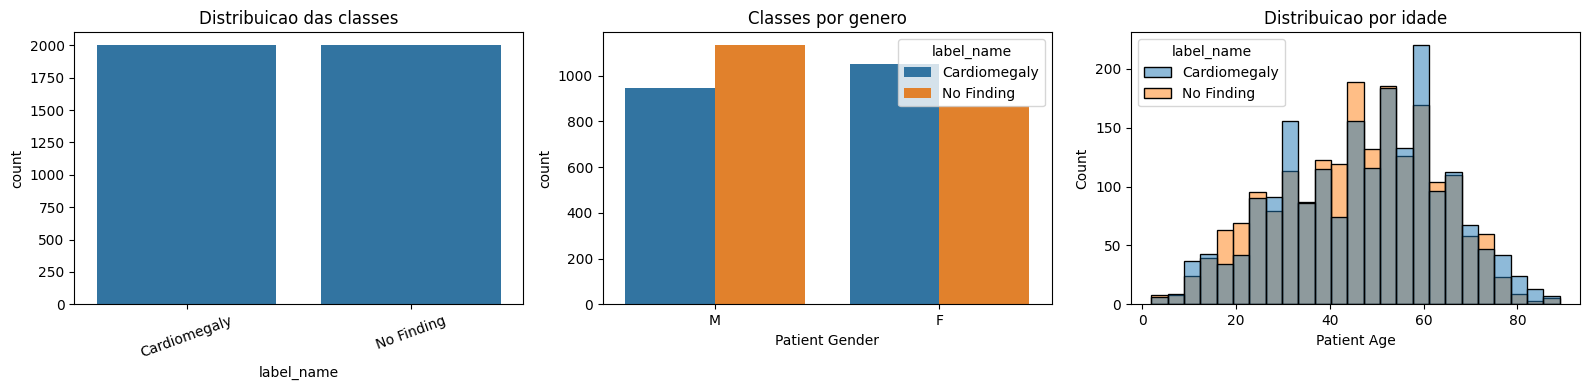

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.countplot(data=dataset_df, x='label_name', ax=axes[0])
axes[0].set_title('Distribuicao das classes')
axes[0].tick_params(axis='x', rotation=20)

sns.countplot(data=dataset_df, x='Patient Gender', hue='label_name', ax=axes[1])
axes[1].set_title('Classes por genero')

sns.histplot(data=dataset_df, x='Patient Age', hue='label_name', bins=25, ax=axes[2])
axes[2].set_title('Distribuicao por idade')

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'eda_recorte_modelagem.png', dpi=160, bbox_inches='tight')
plt.show()

## 2.1. Analise exploratoria aprofundada (EDA)

A FIAP costuma valorizar bastante a leitura exploratoria antes da modelagem. Aqui investigamos distribuicao dos achados, prevalencia de cardiomegalia, quantidade de labels por imagem, idade, genero, quantidade de imagens por paciente e dimensoes reais das imagens.

Essa etapa ajuda a justificar tres decisoes do projeto:

- usar um recorte binario cardiologico (`Cardiomegaly` vs `No Finding`);
- fazer split por paciente para reduzir vazamento de informacao;
- incluir fairness por genero e idade.

In [33]:
# EDA geral do dataset completo apos limpeza basica e associacao com paths de imagem.

required_columns = [
    'Image Index',
    'Finding Labels',
    'Patient ID',
    'Patient Age',
    'Patient Gender',
    'View Position',
]
missing_required_columns = [column for column in required_columns if column not in df.columns]
if missing_required_columns:
    raise ValueError(f'Colunas obrigatorias ausentes: {missing_required_columns}')

eda_df = df.copy()
eda_df['label_list'] = eda_df['Finding Labels'].str.split('|')
eda_df['label_count'] = eda_df['label_list'].str.len()
eda_df['is_cardiomegaly_only'] = eda_df['Finding Labels'].eq(TARGET_POSITIVE)
eda_df['is_multilabel'] = eda_df['label_count'] > 1
eda_df['age_group'] = pd.cut(
    eda_df['Patient Age'],
    bins=[0, 18, 40, 60, 80, 120],
    labels=['0-18', '19-40', '41-60', '61-80', '81+'],
    include_lowest=True,
)

finding_counts = (
    eda_df[['Image Index', 'label_list']]
    .explode('label_list')
    .rename(columns={'label_list': 'finding'})
    .groupby('finding', as_index=False)['Image Index']
    .count()
    .rename(columns={'Image Index': 'image_count'})
    .sort_values('image_count', ascending=False)
)

patient_counts = eda_df.groupby('Patient ID').size().rename('image_count_per_patient').reset_index()
null_counts = eda_df[required_columns].isna().sum().sort_values(ascending=False)
duplicate_image_rows = int(eda_df.duplicated(subset=['Image Index']).sum())
cardio_prevalence = eda_df['has_cardiomegaly'].mean()
no_finding_share = eda_df['is_no_finding'].mean()
cardiomegaly_only_count = int(eda_df['is_cardiomegaly_only'].sum())
cardiomegaly_with_other_count = int((eda_df['has_cardiomegaly'] & eda_df['is_multilabel']).sum())
multilabel_count = int(eda_df['is_multilabel'].sum())

summary_rows = [
    {'metric': 'linhas totais', 'value': len(eda_df)},
    {'metric': 'colunas totais', 'value': len(eda_df.columns)},
    {'metric': 'imagens unicas', 'value': eda_df['Image Index'].nunique()},
    {'metric': 'linhas duplicadas por imagem', 'value': duplicate_image_rows},
    {'metric': 'imagens com path encontrado', 'value': len(eda_df)},
    {'metric': 'pacientes unicos', 'value': eda_df['Patient ID'].nunique()},
    {'metric': 'achados unicos', 'value': finding_counts['finding'].nunique()},
    {'metric': 'prevalencia Cardiomegaly', 'value': round(cardio_prevalence, 4)},
    {'metric': 'proporcao No Finding', 'value': round(no_finding_share, 4)},
    {'metric': 'Cardiomegaly qualquer label', 'value': int(eda_df['has_cardiomegaly'].sum())},
    {'metric': 'Cardiomegaly isolada', 'value': cardiomegaly_only_count},
    {'metric': 'Cardiomegaly com outros achados', 'value': cardiomegaly_with_other_count},
    {'metric': 'imagens multi-label', 'value': multilabel_count},
    {'metric': 'media de labels por imagem', 'value': round(eda_df['label_count'].mean(), 3)},
    {'metric': 'media de imagens por paciente', 'value': round(patient_counts['image_count_per_patient'].mean(), 3)},
]
eda_summary_df = pd.DataFrame(summary_rows)
eda_summary_df.to_csv(TABLES_DIR / 'eda_validacao_e_resumo.csv', index=False)
null_counts.to_csv(TABLES_DIR / 'eda_nulos_colunas_principais.csv', header=['null_count'])
finding_counts.to_csv(TABLES_DIR / 'eda_distribuicao_achados.csv', index=False)
patient_counts.to_csv(TABLES_DIR / 'eda_imagens_por_paciente.csv', index=False)

display(eda_summary_df)
display(null_counts.to_frame('null_count'))
display(finding_counts.head(15))

,metric,value
0,linhas totais,112104.0000
1,colunas totais,20.0000
2,imagens unicas,112104.0000
3,linhas duplicadas por imagem,0.0000
4,imagens com path encontrado,112104.0000
5,pacientes unicos,30802.0000
6,achados unicos,15.0000
7,prevalencia Cardiomegaly,0.0248
8,proporcao No Finding,0.5384
9,Cardiomegaly qualquer label,2776.0000


,null_count
Image Index,0
Finding Labels,0
Patient ID,0
Patient Age,0
Patient Gender,0
View Position,0


,finding,image_count
10,No Finding,60353
8,Infiltration,19891
4,Effusion,13316
0,Atelectasis,11558
11,Nodule,6331
9,Mass,5779
14,Pneumothorax,5301
2,Consolidation,4667
12,Pleural_Thickening,3384
1,Cardiomegaly,2776


In [34]:
# Tabelas de foco do problema e taxas por subgrupo, inspiradas na EDA anterior do projeto.

binary_focus_summary = pd.DataFrame(
    {
        'metric': [
            'no_finding_exact',
            'has_cardiomegaly_any_label',
            'cardiomegaly_only',
            'cardiomegaly_with_other_findings',
            'multilabel_rows_total',
        ],
        'image_count': [
            int(eda_df['is_no_finding'].sum()),
            int(eda_df['has_cardiomegaly'].sum()),
            int(eda_df['is_cardiomegaly_only'].sum()),
            int((eda_df['has_cardiomegaly'] & eda_df['is_multilabel']).sum()),
            int(eda_df['is_multilabel'].sum()),
        ],
    }
)
binary_focus_summary['percentage_of_rows'] = binary_focus_summary['image_count'] / len(eda_df) * 100
binary_focus_summary.to_csv(TABLES_DIR / 'eda_resumo_no_finding_cardiomegaly.csv', index=False)

def subgroup_rate_table(data, group_col):
    grouped = (
        data.groupby(group_col, dropna=False)
        .agg(
            image_count=('Image Index', 'count'),
            cardiomegaly_count=('has_cardiomegaly', 'sum'),
            no_finding_count=('is_no_finding', 'sum'),
            multilabel_count=('is_multilabel', 'sum'),
        )
        .reset_index()
    )
    grouped['cardiomegaly_rate'] = grouped['cardiomegaly_count'] / grouped['image_count']
    grouped['no_finding_rate'] = grouped['no_finding_count'] / grouped['image_count']
    grouped['multilabel_rate'] = grouped['multilabel_count'] / grouped['image_count']
    return grouped.sort_values('image_count', ascending=False)

gender_rates = subgroup_rate_table(eda_df, 'Patient Gender')
view_rates = subgroup_rate_table(eda_df, 'View Position')
age_rates = subgroup_rate_table(eda_df, 'age_group')

gender_rates.to_csv(TABLES_DIR / 'eda_taxas_por_genero.csv', index=False)
view_rates.to_csv(TABLES_DIR / 'eda_taxas_por_posicao_imagem.csv', index=False)
age_rates.to_csv(TABLES_DIR / 'eda_taxas_por_faixa_etaria.csv', index=False)

display(binary_focus_summary)
display(gender_rates)
display(view_rates)
display(age_rates)

,metric,image_count,percentage_of_rows
0,no_finding_exact,60353,53.836616
1,has_cardiomegaly_any_label,2776,2.476272
2,cardiomegaly_only,1093,0.974988
3,cardiomegaly_with_other_findings,1683,1.501285
4,multilabel_rows_total,20792,18.547063


,Patient Gender,image_count,cardiomegaly_count,no_finding_count,multilabel_count,cardiomegaly_rate,no_finding_rate,multilabel_rate
1,M,63328,1307,33916,11993,0.020639,0.535561,0.189379
0,F,48776,1469,26437,8799,0.030117,0.542008,0.180396


,View Position,image_count,cardiomegaly_count,no_finding_count,multilabel_count,cardiomegaly_rate,no_finding_rate,multilabel_rate
1,PA,67299,1563,39296,10178,0.023225,0.583902,0.151236
0,AP,44805,1213,21057,10614,0.027073,0.469970,0.236893


,age_group,image_count,cardiomegaly_count,no_finding_count,multilabel_count,cardiomegaly_rate,no_finding_rate,multilabel_rate
2,41-60,49502,1170,26386,9346,0.023635,0.533029,0.188800
1,19-40,32014,804,18525,5253,0.025114,0.578653,0.164084
3,61-80,23766,606,11589,4985,0.025499,0.487629,0.209753
0,0-18,5941,157,3479,984,0.026427,0.585592,0.165629
4,81+,881,39,374,224,0.044268,0.424518,0.254257


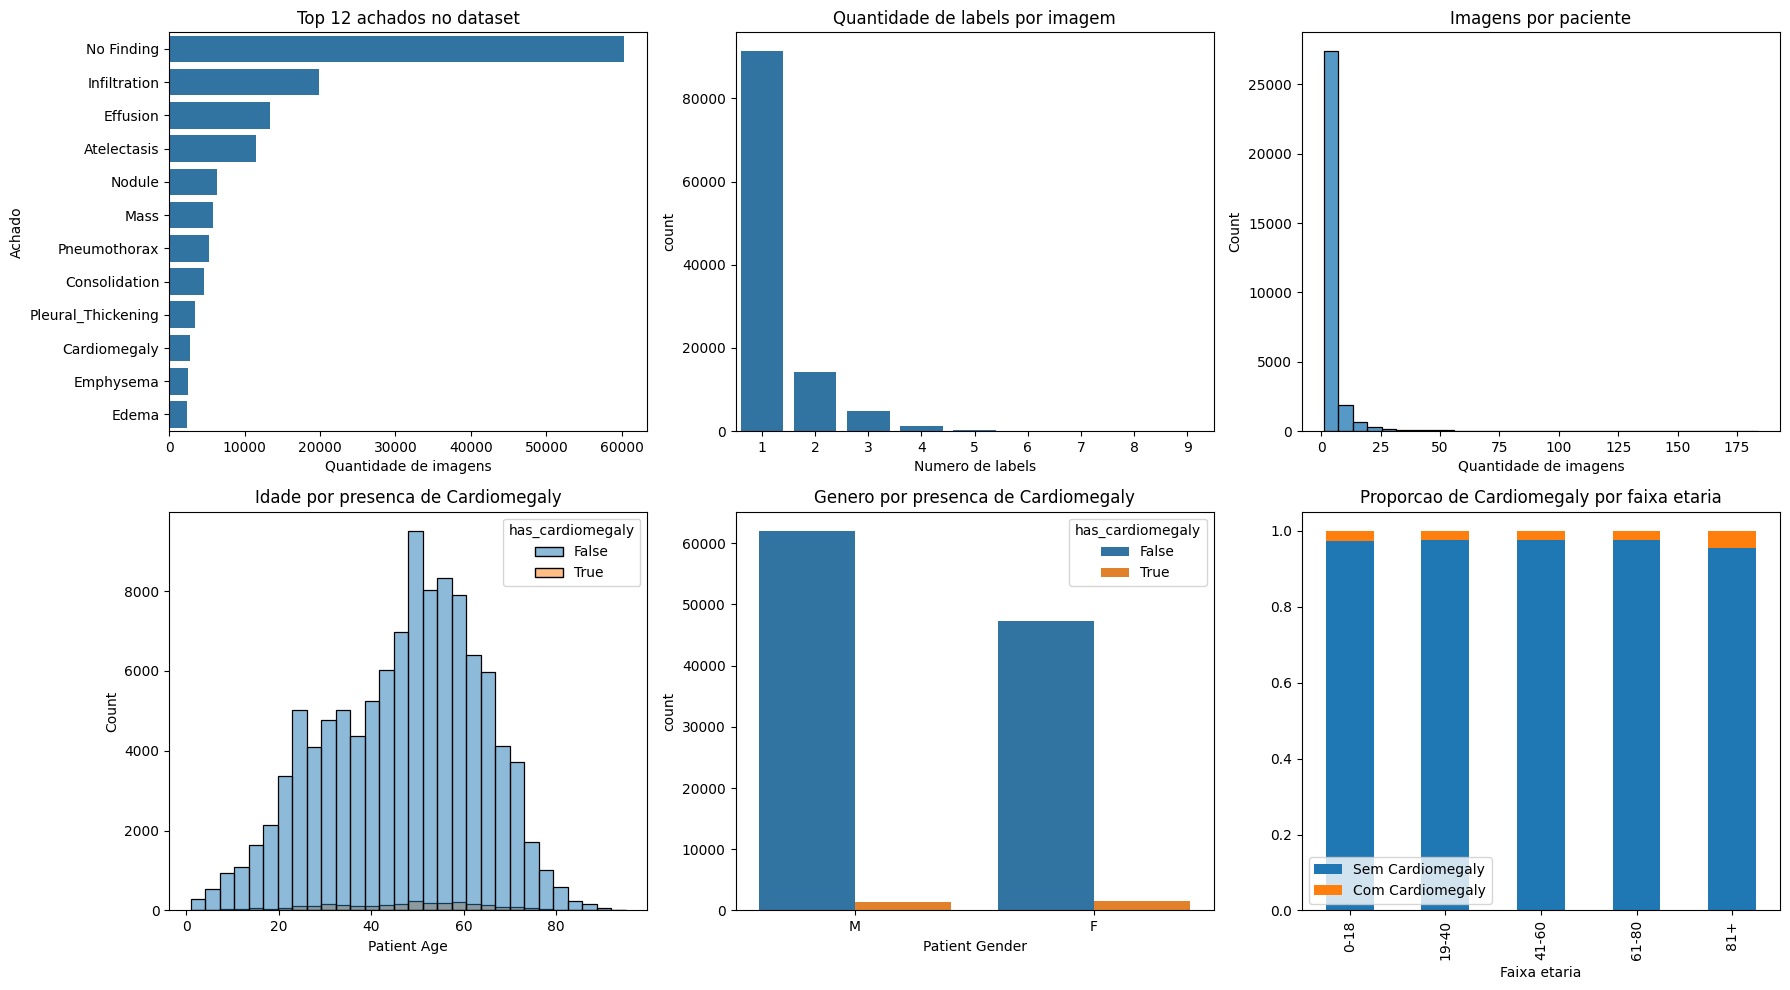

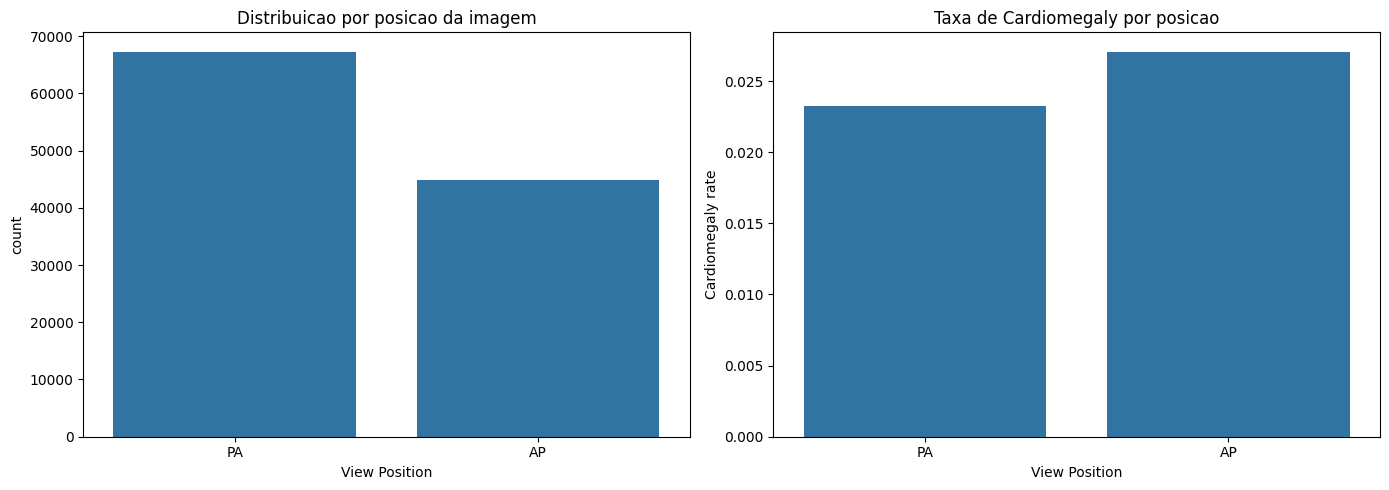

In [35]:
# Visualizacoes exploratorias do dataset completo.

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.barplot(data=finding_counts.head(12), y='finding', x='image_count', ax=axes[0, 0])
axes[0, 0].set_title('Top 12 achados no dataset')
axes[0, 0].set_xlabel('Quantidade de imagens')
axes[0, 0].set_ylabel('Achado')

sns.countplot(data=eda_df, x='label_count', ax=axes[0, 1])
axes[0, 1].set_title('Quantidade de labels por imagem')
axes[0, 1].set_xlabel('Numero de labels')

sns.histplot(data=patient_counts, x='image_count_per_patient', bins=30, ax=axes[0, 2])
axes[0, 2].set_title('Imagens por paciente')
axes[0, 2].set_xlabel('Quantidade de imagens')

sns.histplot(data=eda_df, x='Patient Age', hue='has_cardiomegaly', bins=30, ax=axes[1, 0])
axes[1, 0].set_title('Idade por presenca de Cardiomegaly')

sns.countplot(data=eda_df, x='Patient Gender', hue='has_cardiomegaly', ax=axes[1, 1])
axes[1, 1].set_title('Genero por presenca de Cardiomegaly')

age_group_table = pd.crosstab(eda_df['age_group'], eda_df['has_cardiomegaly'], normalize='index')
age_group_table.plot(kind='bar', stacked=True, ax=axes[1, 2])
axes[1, 2].set_title('Proporcao de Cardiomegaly por faixa etaria')
axes[1, 2].set_xlabel('Faixa etaria')
axes[1, 2].legend(['Sem Cardiomegaly', 'Com Cardiomegaly'], loc='best')

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'eda_visao_geral_dataset.png', dpi=160, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=eda_df, x='View Position', ax=axes[0])
axes[0].set_title('Distribuicao por posicao da imagem')
axes[0].set_xlabel('View Position')

sns.barplot(data=view_rates, x='View Position', y='cardiomegaly_rate', ax=axes[1])
axes[1].set_title('Taxa de Cardiomegaly por posicao')
axes[1].set_ylabel('Cardiomegaly rate')

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'eda_posicao_imagem.png', dpi=160, bbox_inches='tight')
plt.show()

Patient Gender,F,M,All
label_name,,,
Cardiomegaly,1053,947,2000
No Finding,867,1133,2000
All,1920,2080,4000


age_group,0-18,19-40,41-60,61-80,81+,All
label_name,,,,,,
Cardiomegaly,114,595,832,433,26,2000
No Finding,125,583,884,395,13,2000
All,239,1178,1716,828,39,4000


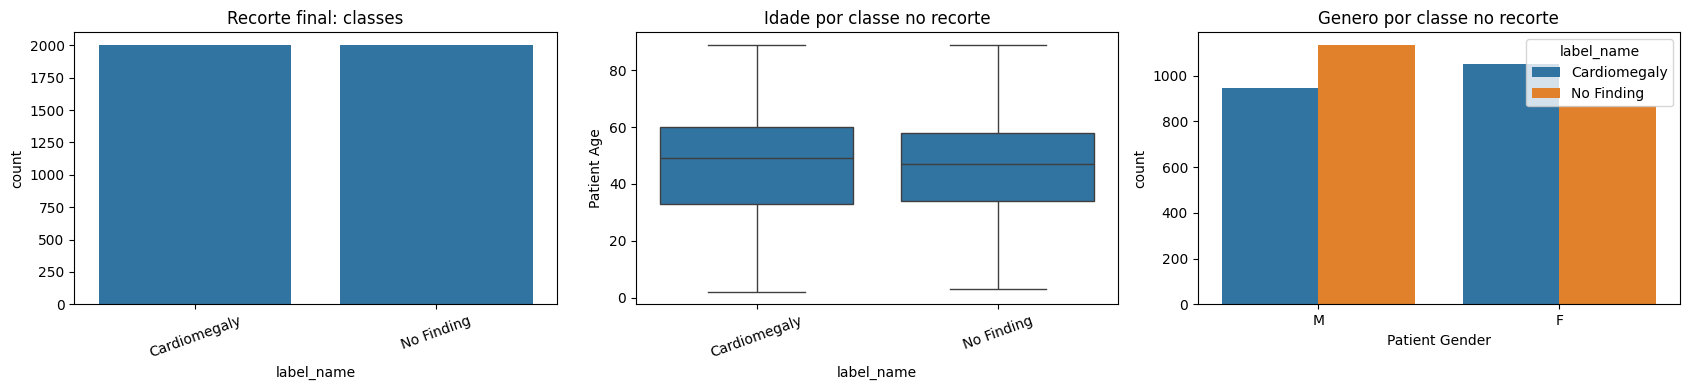

In [36]:
# EDA focada no recorte usado para modelagem.

model_eda = dataset_df.copy()
model_eda['age_group'] = pd.cut(
    model_eda['Patient Age'],
    bins=[0, 18, 40, 60, 80, 120],
    labels=['0-18', '19-40', '41-60', '61-80', '81+'],
    include_lowest=True,
)

display(pd.crosstab(model_eda['label_name'], model_eda['Patient Gender'], margins=True))
display(pd.crosstab(model_eda['label_name'], model_eda['age_group'], margins=True))

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
sns.countplot(data=model_eda, x='label_name', ax=axes[0])
axes[0].set_title('Recorte final: classes')
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=model_eda, x='label_name', y='Patient Age', ax=axes[1])
axes[1].set_title('Idade por classe no recorte')
axes[1].tick_params(axis='x', rotation=20)

sns.countplot(data=model_eda, x='Patient Gender', hue='label_name', ax=axes[2])
axes[2].set_title('Genero por classe no recorte')

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'eda_dimensoes_imagens.png', dpi=160, bbox_inches='tight')
plt.show()

,width,height,mode
count,200.0,200.0,200
unique,NaN,NaN,2
top,NaN,NaN,L
freq,NaN,NaN,197
mean,1024.0,1024.0,NaN
std,0.0,0.0,NaN
min,1024.0,1024.0,NaN
25%,1024.0,1024.0,NaN
50%,1024.0,1024.0,NaN
75%,1024.0,1024.0,NaN


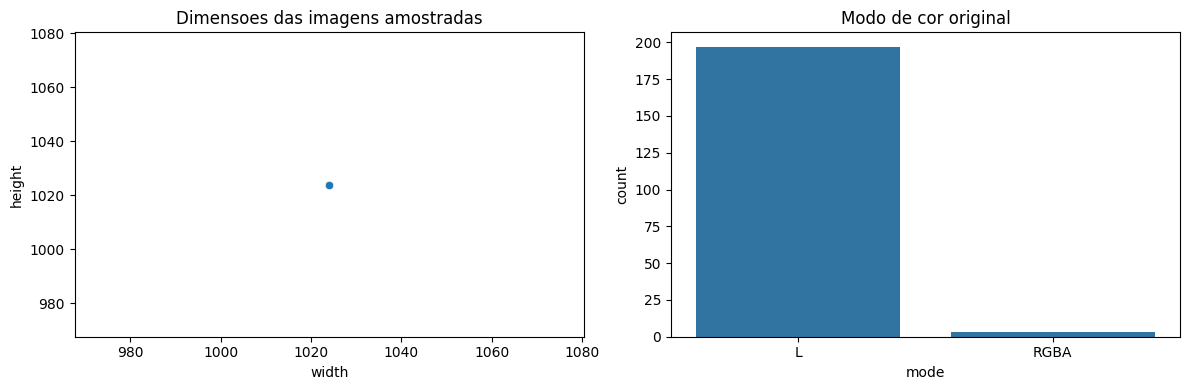

In [37]:
# Inspecao de dimensoes das imagens. Amostramos algumas imagens para confirmar padrao visual e necessidade de resize.

sample_paths = model_eda['path'].sample(n=min(200, len(model_eda)), random_state=SEED)
image_shape_rows = []
for path in sample_paths:
    with Image.open(path) as img:
        image_shape_rows.append({'width': img.width, 'height': img.height, 'mode': img.mode})

image_shapes_df = pd.DataFrame(image_shape_rows)
display(image_shapes_df.describe(include='all'))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(data=image_shapes_df, x='width', y='height', ax=axes[0])
axes[0].set_title('Dimensoes das imagens amostradas')
sns.countplot(data=image_shapes_df, x='mode', ax=axes[1])
axes[1].set_title('Modo de cor original')
plt.tight_layout()
plt.show()

### Leituras esperadas da EDA

- `No Finding` costuma ser uma das classes mais frequentes, enquanto `Cardiomegaly` e relativamente menos prevalente no dataset completo.
- O dataset e multi-label, entao imagens com `Cardiomegaly` podem carregar outros achados associados. Isso justifica documentar que o problema binario e uma simplificacao.
- A quantidade de imagens por paciente reforca a necessidade do split por `Patient ID`, evitando que imagens do mesmo paciente aparecam em treino e teste.
- Diferencas por idade e genero justificam a etapa posterior de fairness.
- A analise de dimensoes confirma a necessidade de redimensionamento padronizado para entrada dos modelos.

In [38]:
# Conclusoes objetivas da EDA para apoiar o relatorio tecnico.

total_rows = len(eda_df)
no_finding_count = int(eda_df['is_no_finding'].sum())
cardiomegaly_any_count = int(eda_df['has_cardiomegaly'].sum())
cardiomegaly_only_count = int(eda_df['is_cardiomegaly_only'].sum())
multilabel_count = int(eda_df['is_multilabel'].sum())

eda_conclusions = [
    {
        'question': 'O dataset e balanceado?',
        'answer': 'Nao. A distribuicao de achados mostra diferencas importantes entre as classes, justificando amostragem balanceada e pos_weight no treino.',
    },
    {
        'question': 'Quantas imagens No Finding existem?',
        'answer': f'{no_finding_count:,} imagens ({no_finding_count / total_rows:.2%} das linhas analisadas).',
    },
    {
        'question': 'Quantas imagens contem Cardiomegaly?',
        'answer': f'{cardiomegaly_any_count:,} imagens contem Cardiomegaly em qualquer label; {cardiomegaly_only_count:,} imagens possuem apenas Cardiomegaly.',
    },
    {
        'question': 'Existem casos multi-label relevantes?',
        'answer': f'{multilabel_count:,} imagens possuem mais de uma label ({multilabel_count / total_rows:.2%}). Isso confirma que o problema binario e uma simplificacao controlada.',
    },
    {
        'question': 'Por que usar split por paciente?',
        'answer': 'Ha pacientes com multiplas imagens. Separar por Patient ID reduz o risco de vazamento entre treino, validacao e teste.',
    },
    {
        'question': 'Quais variaveis entram na discussao de governanca?',
        'answer': 'Genero, idade e View Position mostram distribuicoes/taxas diferentes e devem ser monitorados na avaliacao e fairness.',
    },
]

eda_conclusions_df = pd.DataFrame(eda_conclusions)
eda_conclusions_df.to_csv(TABLES_DIR / 'eda_conclusoes.csv', index=False)
display(eda_conclusions_df)

print('Tabelas e figuras da EDA salvas em:', ARTIFACT_DIR.resolve())

,question,answer
0,O dataset e balanceado?,Nao. A distribuicao de achados mostra diferenc...
1,Quantas imagens No Finding existem?,"60,353 imagens (53.84% das linhas analisadas)."
2,Quantas imagens contem Cardiomegaly?,"2,776 imagens contem Cardiomegaly em qualquer ..."
3,Existem casos multi-label relevantes?,"20,792 imagens possuem mais de uma label (18.5..."
4,Por que usar split por paciente?,Ha pacientes com multiplas imagens. Separar po...
5,Quais variaveis entram na discussao de governa...,"Genero, idade e View Position mostram distribu..."


Tabelas e figuras da EDA salvas em: C:\FIAP\fase4\fiap_fase4\notebooks\artifacts_cardioia_pytorch


## 3. Split por paciente

Para evitar vazamento de informacao, imagens do mesmo paciente nao devem aparecer simultaneamente em treino e teste. Usamos `Patient ID` como grupo.

In [39]:
def group_split(dataframe, test_size, seed):
    splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    train_idx, test_idx = next(splitter.split(dataframe, groups=dataframe['Patient ID']))
    return dataframe.iloc[train_idx].copy(), dataframe.iloc[test_idx].copy()

train_df, temp_df = group_split(dataset_df, test_size=0.30, seed=SEED)
val_df, test_df = group_split(temp_df, test_size=0.50, seed=SEED + 1)

for name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(name, split_df.shape, split_df[LABEL_COL].value_counts(normalize=True).round(3).to_dict(), 'pacientes:', split_df['Patient ID'].nunique())

train_df.to_csv(ARTIFACT_DIR / 'train_split.csv', index=False)
val_df.to_csv(ARTIFACT_DIR / 'val_split.csv', index=False)
test_df.to_csv(ARTIFACT_DIR / 'test_split.csv', index=False)

train (2800, 17) {1: 0.506, 0: 0.494} pacientes: 2045
val (585, 17) {0: 0.538, 1: 0.462} pacientes: 438
test (615, 17) {1: 0.507, 0: 0.493} pacientes: 439


## 4. Dataset, transforms e DataLoader

Pre-processamento aplicado:

- leitura da imagem PNG;
- conversao para RGB;
- redimensionamento para 224x224;
- transformacao para tensor;
- normalizacao ImageNet para compatibilidade com modelos pre-treinados;
- data augmentation apenas no treino da CNN melhorada e modelos treinados com `train_transform`.

In [40]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row['path']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label = torch.tensor(row[LABEL_COL], dtype=torch.float32)
        return image, label

def make_loader(dataframe, transform, shuffle=False):
    ds = ChestXrayDataset(dataframe, transform=transform)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

train_loader = make_loader(train_df, train_transform, shuffle=True)
val_loader = make_loader(val_df, eval_transform)
test_loader = make_loader(test_df, eval_transform)

batch_images, batch_labels = next(iter(train_loader))
print(batch_images.shape, batch_labels.shape)

torch.Size([128, 3, 224, 224]) torch.Size([128])


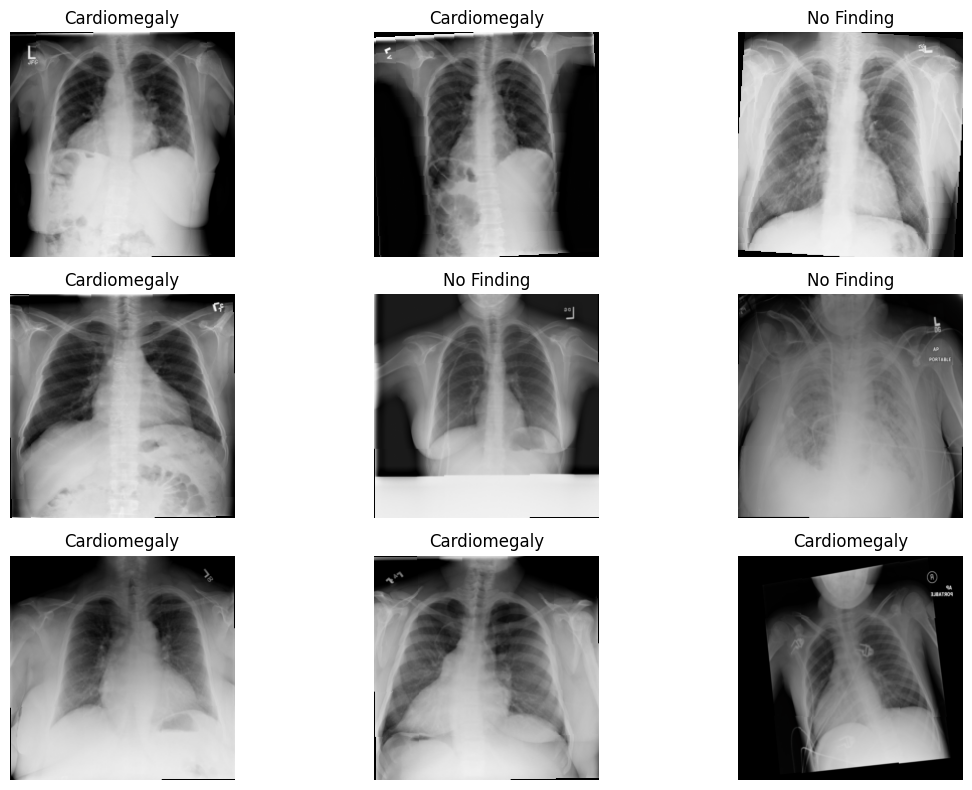

In [41]:
def denormalize(img_tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img = img_tensor.cpu() * std + mean
    return img.clamp(0, 1).permute(1, 2, 0).numpy()

plt.figure(figsize=(12, 8))
for i in range(min(9, len(batch_images))):
    plt.subplot(3, 3, i + 1)
    plt.imshow(denormalize(batch_images[i]))
    plt.title(TARGET_POSITIVE if int(batch_labels[i].item()) == 1 else TARGET_NEGATIVE)
    plt.axis('off')
plt.tight_layout()
plt.show()

## 5. Funcoes de treino e avaliacao

Todos os modelos retornam **um logit**. Usamos `BCEWithLogitsLoss`, `sigmoid` na avaliacao e threshold padrao de 0.5.

In [42]:
pos_count = train_df[LABEL_COL].sum()
neg_count = len(train_df) - pos_count
POS_WEIGHT = torch.tensor([neg_count / max(pos_count, 1)], dtype=torch.float32).to(DEVICE)
print('pos_weight:', POS_WEIGHT.item())

DEBUG_DEVICE_ONCE = True

def train_one_epoch(model, loader, optimizer, criterion, scaler=None):
    global DEBUG_DEVICE_ONCE
    model.train()
    total_loss = 0.0
    for images, labels in tqdm(loader, leave=False):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True).view(-1, 1)
        if DEBUG_DEVICE_ONCE:
            print('Device do modelo:', next(model.parameters()).device)
            print('Device das imagens:', images.device)
            print('Device dos labels:', labels.device)
            print_gpu_status('Durante o treino:')
            DEBUG_DEVICE_ONCE = False
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(images)
            loss = criterion(logits, labels)
        if scaler is not None and USE_AMP:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * images.size(0)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def predict_proba(model, loader):
    model.eval()
    y_true, y_proba = [], []
    for images, labels in tqdm(loader, leave=False):
        images = images.to(DEVICE, non_blocking=True)
        logits = model(images).detach().cpu().view(-1)
        probs = torch.sigmoid(logits).numpy()
        y_proba.extend(probs.tolist())
        y_true.extend(labels.numpy().astype(int).tolist())
    return np.array(y_true), np.array(y_proba)

def compute_metrics(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'specificity': specificity,
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_proba) if len(np.unique(y_true)) == 2 else np.nan,
        'pr_auc': average_precision_score(y_true, y_proba),
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
        'threshold': threshold,
    }

def plot_confusion(y_true, y_proba, title, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[TARGET_NEGATIVE, TARGET_POSITIVE], yticklabels=[TARGET_NEGATIVE, TARGET_POSITIVE])
    plt.xlabel('Previsto')
    plt.ylabel('Real')
    plt.title(title)
    plt.tight_layout()
    plt.show()

def fit_model(model, model_name, epochs, lr=1e-3, weight_decay=1e-4):
    model = model.to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT)
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.3, patience=2)
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    best_state = None
    best_val_f1 = -1
    history = []
    patience = 4
    patience_left = patience

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
        y_val, p_val = predict_proba(model, val_loader)
        val_metrics = compute_metrics(y_val, p_val)
        scheduler.step(val_metrics['f1'])
        row = {'epoch': epoch, 'train_loss': train_loss, **val_metrics}
        history.append(row)
        print(f"{model_name} | epoch {epoch}/{epochs} | loss={train_loss:.4f} | val_f1={val_metrics['f1']:.4f} | val_auc={val_metrics['roc_auc']:.4f}")
        if val_metrics['f1'] > best_val_f1:
            best_val_f1 = val_metrics['f1']
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_left = patience
        else:
            patience_left -= 1
            if patience_left <= 0:
                print('Early stopping')
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

experiment_results = []
predictions_registry = {}
trained_models_registry = {}

def count_parameters(model):
    total_parameters = sum(parameter.numel() for parameter in model.parameters())
    trainable_parameters = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
    return total_parameters, trainable_parameters

@torch.no_grad()
def benchmark_inference(model, loader, max_batches=10):
    model.eval()
    total_images = 0
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    start_time = time.perf_counter()
    for batch_index, (images, _) in enumerate(loader):
        if batch_index >= max_batches:
            break
        images = images.to(DEVICE, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            _ = model(images)
        total_images += images.size(0)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    elapsed_time = time.perf_counter() - start_time
    return elapsed_time / max(total_images, 1)

def evaluate_model(model, model_name):
    model = model.to(DEVICE)
    y_true, y_proba = predict_proba(model, test_loader)
    metrics = compute_metrics(y_true, y_proba)
    total_parameters, trainable_parameters = count_parameters(model)
    checkpoint_path = MODELS_DIR / f'{model_name.replace(" ", "_").lower()}.pt'
    torch.save(model.state_dict(), checkpoint_path)
    metrics['model'] = model_name
    metrics['model_name'] = model_name
    metrics['auc_roc'] = metrics['roc_auc']
    metrics['seconds_per_image'] = benchmark_inference(model, test_loader)
    metrics['total_parameters'] = total_parameters
    metrics['trainable_parameters'] = trainable_parameters
    metrics['checkpoint_path'] = str(checkpoint_path)
    metrics['checkpoint_size_bytes'] = checkpoint_path.stat().st_size if checkpoint_path.exists() else np.nan
    experiment_results.append(metrics)
    trained_models_registry[model_name] = model
    predictions_registry[model_name] = pd.DataFrame({
        'Image Index': test_df['Image Index'].values,
        'Patient ID': test_df['Patient ID'].values,
        'Patient Gender': test_df['Patient Gender'].values,
        'Patient Age': test_df['Patient Age'].values,
        'View Position': test_df['View Position'].values,
        'y_true': y_true,
        'y_proba': y_proba,
        'y_pred': (y_proba >= 0.5).astype(int),
    })
    print(model_name)
    print(classification_report(y_true, (y_proba >= 0.5).astype(int), target_names=[TARGET_NEGATIVE, TARGET_POSITIVE], zero_division=0))
    print(f"Inferencia media: {metrics['seconds_per_image']:.6f} s/imagem | Parametros: {total_parameters:,} | Checkpoint: {metrics['checkpoint_size_bytes'] / (1024 ** 2):.2f} MB")
    plot_confusion(y_true, y_proba, f'Matriz de confusao - {model_name}')
    return metrics

pos_weight: 0.9746121168136597


## 6. Modelo 1 - CNN base do zero

Este e o algoritmo base pedido no enunciado: uma CNN simples treinada do zero.

In [ ]:
class BaseCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 128), nn.ReLU(),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

base_cnn = BaseCNN()
if RUN_FULL_TRAINING:
    base_cnn, history_base = fit_model(base_cnn, 'CNN base', EPOCHS_BASE, lr=1e-3)
    display(history_base)
    evaluate_model(base_cnn, 'CNN base')

C:\Users\felip\AppData\Local\Temp\ipykernel_27600\1860848837.py:80: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
  0%|          | 0/22 [00:00<?, ?it/s]

Device do modelo: cuda:0
Device das imagens: cuda:0
Device dos labels: cuda:0
Durante o treino: DEVICE = cuda
Durante o treino: GPU = NVIDIA GeForce RTX 5070 Ti
Durante o treino: Memoria alocada MB = 527.8
Durante o treino: Memoria reservada MB = 2016.0


C:\Users\felip\AppData\Local\Temp\ipykernel_27600\1860848837.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


CNN base | epoch 1/8 | loss=1.1707 | val_f1=0.6550 | val_auc=0.7134


  0%|          | 0/22 [00:00<?, ?it/s]C:\Users\felip\AppData\Local\Temp\ipykernel_27600\1860848837.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
 95%|█████████▌| 21/22 [00:27<00:01,  1.29s/it]

## 7. Modelo 2 - CNN melhorada

Melhorias aplicadas sobre a CNN base:

- blocos com `BatchNorm2d`;
- `Dropout`;
- `AdaptiveAvgPool2d`, reduzindo parametros;
- `AdamW`;
- `pos_weight` para balanceamento;
- augmentation no `DataLoader` de treino;
- early stopping por F1 de validacao.

C:\Users\felip\AppData\Local\Temp\ipykernel_27600\1860848837.py:80: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
  0%|          | 0/22 [00:00<?, ?it/s]C:\Users\felip\AppData\Local\Temp\ipykernel_27600\1860848837.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


CNN melhorada | epoch 1/12 | loss=0.6589 | val_f1=0.5882 | val_auc=0.4978


  0%|          | 0/22 [00:00<?, ?it/s]C:\Users\felip\AppData\Local\Temp\ipykernel_27600\1860848837.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


CNN melhorada | epoch 2/12 | loss=0.6266 | val_f1=0.3469 | val_auc=0.6729


  0%|          | 0/22 [00:00<?, ?it/s]C:\Users\felip\AppData\Local\Temp\ipykernel_27600\1860848837.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


...

  0%|          | 0/22 [00:00<?, ?it/s]C:\Users\felip\AppData\Local\Temp\ipykernel_27600\1860848837.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
                                               

CNN melhorada | epoch 12/12 | loss=0.5248 | val_f1=0.7217 | val_auc=0.7961


,epoch,train_loss,accuracy,precision,recall,specificity,f1,roc_auc,pr_auc,tn,fp,fn,tp,threshold
0,1,0.658940,0.449573,0.449219,0.851852,0.104762,0.588235,0.497754,0.469850,33,282,40,230,0.5
1,2,0.626581,0.588034,0.646465,0.237037,0.888889,0.346883,0.672922,0.606047,280,35,206,64,0.5
2,3,0.611443,0.603419,0.546341,0.829630,0.409524,0.658824,0.706267,0.641739,129,186,46,224,0.5
3,4,0.591747,0.687179,0.653710,0.685185,0.688889,0.669078,0.763668,0.730243,217,98,85,185,0.5
4,5,0.589732,0.620513,0.553333,0.922222,0.361905,0.691667,0.737460,0.661522,114,201,21,249,0.5
5,6,0.578408,0.692308,0.655172,0.703704,0.682540,0.678571,0.763410,0.696087,215,100,80,190,0.5
6,7,0.578401,0.709402,0.704918,0.637037,0.771429,0.669261,0.778131,0.724909,243,72,98,172,0.5
7,8,0.560682,0.615385,0.736842,0.259259,0.920635,0.383562,0.772499,0.713094,290,25,200,70,0.5
8,9,0.549819,0.711111,0.636856,0.870370,0.574603,0.735524,0.798330,0.753405,181,134,35,235,0.5
9,10,0.533456,0.721368,0.674267,0.766667,0.682540,0.717504,0.784033,0.724619,215,100,63,207,0.5


C:\Users\felip\AppData\Local\Temp\ipykernel_27600\1860848837.py:129: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


CNN melhorada
              precision    recall  f1-score   support

  No Finding       0.75      0.72      0.73       303
Cardiomegaly       0.74      0.77      0.75       312

    accuracy                           0.74       615
   macro avg       0.74      0.74      0.74       615
weighted avg       0.74      0.74      0.74       615

Inferencia media: 0.010151 s/imagem | Parametros: 1,206,241 | Checkpoint: 4.63 MB


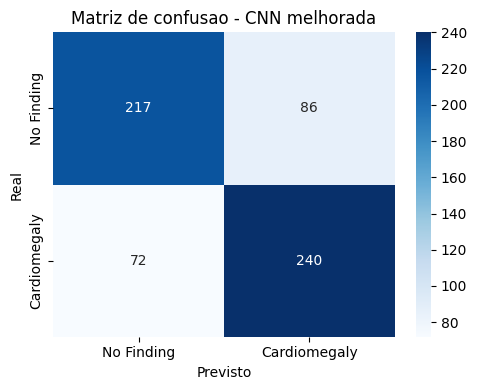

In [ ]:
class ImprovedCNN(nn.Module):
    def __init__(self):
        super().__init__()
        def block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )
        self.features = nn.Sequential(
            block(3, 32),
            block(32, 64),
            block(64, 128),
            block(128, 256),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.35),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

improved_cnn = ImprovedCNN()
if RUN_FULL_TRAINING:
    improved_cnn, history_improved = fit_model(improved_cnn, 'CNN melhorada', EPOCHS_IMPROVED, lr=5e-4)
    display(history_improved)
    evaluate_model(improved_cnn, 'CNN melhorada')

## 8. Transfer Learning - ResNet50, VGG16 e EfficientNetB0

Agora usamos modelos pre-treinados do `torchvision`. Primeiro treinamos apenas o cabecalho de classificacao; depois liberamos parte do backbone para fine-tuning leve.

C:\Users\felip\AppData\Local\Temp\ipykernel_27600\1860848837.py:80: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)



Treinando ResNet50


  0%|          | 0/22 [00:00<?, ?it/s]C:\Users\felip\AppData\Local\Temp\ipykernel_27600\1860848837.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


ResNet50 head | epoch 1/5 | loss=0.6668 | val_f1=0.4764 | val_auc=0.6531


  0%|          | 0/22 [00:00<?, ?it/s]C:\Users\felip\AppData\Local\Temp\ipykernel_27600\1860848837.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


...

  0%|          | 0/22 [00:00<?, ?it/s]C:\Users\felip\AppData\Local\Temp\ipykernel_27600\1860848837.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
                                               

ResNet50 | epoch 4/4 | loss=0.5524 | val_f1=0.7176 | val_auc=0.7804


,epoch,train_loss,accuracy,precision,recall,specificity,f1,roc_auc,pr_auc,tn,fp,fn,tp,threshold,stage
0,1,0.666837,0.601709,0.605714,0.392593,0.780952,0.476404,0.653086,0.565360,246,69,164,106,0.5,head
1,2,0.631489,0.610256,0.554688,0.788889,0.457143,0.651376,0.680694,0.618555,144,171,57,213,0.5,head
2,3,0.615923,0.651282,0.582500,0.862963,0.469841,0.695522,0.721999,0.674384,148,167,37,233,0.5,head
3,4,0.598196,0.683761,0.623188,0.796296,0.587302,0.699187,0.744550,0.680008,185,130,55,215,0.5,head
4,5,0.597488,0.694017,0.626039,0.837037,0.571429,0.716323,0.752922,0.681439,180,135,44,226,0.5,head
5,1,0.577349,0.702564,0.642857,0.800000,0.619048,0.712871,0.761740,0.688544,195,120,54,216,0.5,fine_tune
6,2,0.573377,0.711111,0.655385,0.788889,0.644444,0.715966,0.768760,0.697223,203,112,57,213,0.5,fine_tune
7,3,0.562802,0.712821,0.655488,0.796296,0.641270,0.719064,0.775062,0.708492,202,113,55,215,0.5,fine_tune
8,4,0.552423,0.709402,0.650602,0.800000,0.631746,0.717608,0.780435,0.718723,199,116,54,216,0.5,fine_tune


C:\Users\felip\AppData\Local\Temp\ipykernel_27600\1860848837.py:129: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


ResNet50
              precision    recall  f1-score   support

  No Finding       0.77      0.66      0.71       303
Cardiomegaly       0.71      0.81      0.76       312

    accuracy                           0.74       615
   macro avg       0.74      0.74      0.74       615
weighted avg       0.74      0.74      0.74       615

Inferencia media: 0.010907 s/imagem | Parametros: 23,510,081 | Checkpoint: 89.99 MB


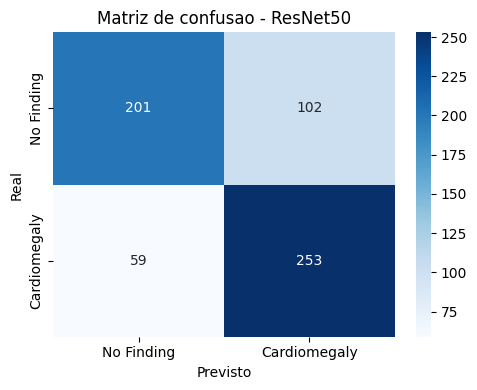


Treinando VGG16


C:\Users\felip\AppData\Local\Temp\ipykernel_27600\1860848837.py:80: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
  0%|          | 0/22 [00:00<?, ?it/s]C:\Users\felip\AppData\Local\Temp\ipykernel_27600\1860848837.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


VGG16 head | epoch 1/5 | loss=0.6699 | val_f1=0.6474 | val_auc=0.7214


  0%|          | 0/22 [00:00<?, ?it/s]C:\Users\felip\AppData\Local\Temp\ipykernel_27600\1860848837.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


VGG16 head | epoch 2/5 | loss=0.6262 | val_f1=0.6642 | val_auc=0.7537


...

  0%|          | 0/22 [00:00<?, ?it/s]C:\Users\felip\AppData\Local\Temp\ipykernel_27600\1860848837.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
                                               

VGG16 | epoch 4/4 | loss=0.5248 | val_f1=0.7525 | val_auc=0.8242


,epoch,train_loss,accuracy,precision,recall,specificity,f1,roc_auc,pr_auc,tn,fp,fn,tp,threshold,stage
0,1,0.669855,0.666667,0.632509,0.662963,0.669841,0.647378,0.721387,0.658310,211,104,91,179,0.5,head
1,2,0.626164,0.685470,0.654676,0.674074,0.695238,0.664234,0.753674,0.687114,219,96,88,182,0.5,head
2,3,0.614290,0.673504,0.672489,0.570370,0.761905,0.617234,0.767343,0.705768,240,75,116,154,0.5,head
3,4,0.611038,0.719658,0.663580,0.796296,0.653968,0.723906,0.767596,0.707607,206,109,55,215,0.5,head
4,5,0.605821,0.675214,0.601010,0.881481,0.498413,0.714715,0.771229,0.710215,157,158,32,238,0.5,head
5,1,0.595208,0.711111,0.640669,0.851852,0.590476,0.731320,0.787607,0.730790,186,129,40,230,0.5,fine_tune
6,2,0.575207,0.736752,0.697279,0.759259,0.717460,0.726950,0.801258,0.749138,226,89,65,205,0.5,fine_tune
7,3,0.545485,0.736752,0.672619,0.837037,0.650794,0.745875,0.815520,0.769740,205,110,44,226,0.5,fine_tune
8,4,0.524834,0.747009,0.685976,0.833333,0.673016,0.752508,0.824209,0.784575,212,103,45,225,0.5,fine_tune


C:\Users\felip\AppData\Local\Temp\ipykernel_27600\1860848837.py:129: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


VGG16
              precision    recall  f1-score   support

  No Finding       0.76      0.67      0.71       303
Cardiomegaly       0.71      0.79      0.75       312

    accuracy                           0.73       615
   macro avg       0.74      0.73      0.73       615
weighted avg       0.74      0.73      0.73       615

Inferencia media: 0.011701 s/imagem | Parametros: 134,264,641 | Checkpoint: 512.19 MB


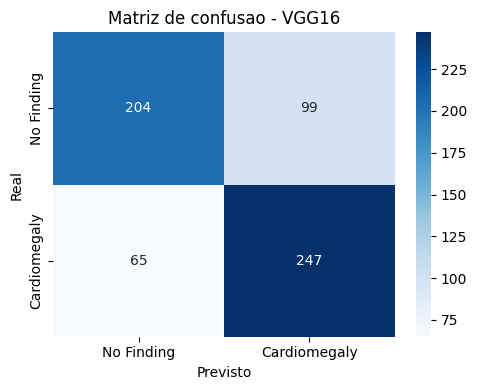

C:\Users\felip\AppData\Local\Temp\ipykernel_27600\1860848837.py:80: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)



Treinando EfficientNetB0


  0%|          | 0/22 [00:00<?, ?it/s]C:\Users\felip\AppData\Local\Temp\ipykernel_27600\1860848837.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


EfficientNetB0 head | epoch 1/5 | loss=0.6596 | val_f1=0.5499 | val_auc=0.7151


  0%|          | 0/22 [00:00<?, ?it/s]C:\Users\felip\AppData\Local\Temp\ipykernel_27600\1860848837.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


...

  0%|          | 0/22 [00:00<?, ?it/s]C:\Users\felip\AppData\Local\Temp\ipykernel_27600\1860848837.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
                                               

EfficientNetB0 | epoch 4/4 | loss=0.5599 | val_f1=0.7383 | val_auc=0.8099


,epoch,train_loss,accuracy,precision,recall,specificity,f1,roc_auc,pr_auc,tn,fp,fn,tp,threshold,stage
0,1,0.659622,0.652991,0.685083,0.459259,0.819048,0.549889,0.715109,0.661419,258,57,146,124,0.5,head
1,2,0.614071,0.676923,0.626168,0.744444,0.619048,0.680203,0.730453,0.672786,195,120,69,201,0.5,head
2,3,0.589156,0.716239,0.684397,0.714815,0.717460,0.699275,0.786784,0.732951,226,89,77,193,0.5,head
3,4,0.582338,0.728205,0.671827,0.803704,0.663492,0.731872,0.798542,0.748200,209,106,53,217,0.5,head
4,5,0.571941,0.738462,0.684543,0.803704,0.682540,0.739353,0.802387,0.750773,215,100,53,217,0.5,head
5,1,0.564652,0.731624,0.681672,0.785185,0.685714,0.729776,0.804339,0.754321,216,99,58,212,0.5,fine_tune
6,2,0.563211,0.738462,0.689320,0.788889,0.695238,0.735751,0.806232,0.756782,219,96,57,213,0.5,fine_tune
7,3,0.555921,0.740171,0.692810,0.785185,0.701587,0.736111,0.807819,0.760000,221,94,58,212,0.5,fine_tune
8,4,0.559877,0.741880,0.693811,0.788889,0.701587,0.738302,0.809935,0.762430,221,94,57,213,0.5,fine_tune


C:\Users\felip\AppData\Local\Temp\ipykernel_27600\1860848837.py:129: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


EfficientNetB0
              precision    recall  f1-score   support

  No Finding       0.72      0.70      0.71       303
Cardiomegaly       0.72      0.74      0.73       312

    accuracy                           0.72       615
   macro avg       0.72      0.72      0.72       615
weighted avg       0.72      0.72      0.72       615

Inferencia media: 0.014000 s/imagem | Parametros: 4,008,829 | Checkpoint: 15.58 MB


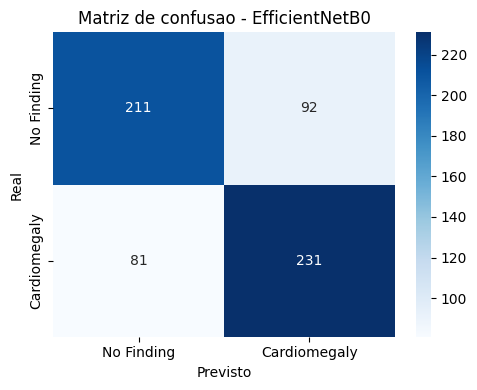

In [ ]:
def set_requires_grad(module, value):
    for param in module.parameters():
        param.requires_grad = value

def build_transfer_model(name):
    if name == 'ResNet50':
        weights = models.ResNet50_Weights.DEFAULT
        model = models.resnet50(weights=weights)
        set_requires_grad(model, False)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, 1)
        fine_tune_modules = [model.layer4]
    elif name == 'VGG16':
        weights = models.VGG16_Weights.DEFAULT
        model = models.vgg16(weights=weights)
        set_requires_grad(model, False)
        in_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_features, 1)
        fine_tune_modules = [model.features[-8:]]
    elif name == 'EfficientNetB0':
        weights = models.EfficientNet_B0_Weights.DEFAULT
        model = models.efficientnet_b0(weights=weights)
        set_requires_grad(model, False)
        in_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_features, 1)
        fine_tune_modules = [model.features[-2:]]
    else:
        raise ValueError(name)
    return model, fine_tune_modules

def train_transfer_model(name):
    model, fine_tune_modules = build_transfer_model(name)
    model, hist_head = fit_model(model, f'{name} head', EPOCHS_TRANSFER_HEAD, lr=1e-3)
    for module in fine_tune_modules:
        set_requires_grad(module, True)
    model, hist_ft = fit_model(model, name, EPOCHS_TRANSFER_FINE_TUNE, lr=1e-5, weight_decay=1e-5)
    history = pd.concat([hist_head.assign(stage='head'), hist_ft.assign(stage='fine_tune')], ignore_index=True)
    display(history)
    evaluate_model(model, name)
    return model, history

transfer_histories = {}
if RUN_FULL_TRAINING and RUN_TRANSFER_MODELS:
    for transfer_name in ['ResNet50', 'VGG16', 'EfficientNetB0']:
        print('\n' + '=' * 80)
        print('Treinando', transfer_name)
        _, transfer_histories[transfer_name] = train_transfer_model(transfer_name)

## 9. Vision Transformer

Incluimos um modelo Transformer de visao (`ViT-B/16`) via `torchvision`. Ele divide a imagem em patches e usa atencao para aprender relacoes globais.

C:\Users\felip\AppData\Local\Temp\ipykernel_27600\1860848837.py:80: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
  0%|          | 0/22 [00:00<?, ?it/s]C:\Users\felip\AppData\Local\Temp\ipykernel_27600\1860848837.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Vision Transformer ViT | epoch 1/5 | loss=0.6435 | val_f1=0.5684 | val_auc=0.7277


  0%|          | 0/22 [00:00<?, ?it/s]C:\Users\felip\AppData\Local\Temp\ipykernel_27600\1860848837.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Vision Transformer ViT | epoch 2/5 | loss=0.5883 | val_f1=0.6091 | val_auc=0.7593


  0%|          | 0/22 [00:00<?, ?it/s]C:\Users\felip\AppData\Local\Temp\ipykernel_27600\1860848837.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


...

  0%|          | 0/22 [00:00<?, ?it/s]C:\Users\felip\AppData\Local\Temp\ipykernel_27600\1860848837.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
                                               

Vision Transformer ViT | epoch 5/5 | loss=0.5392 | val_f1=0.6991 | val_auc=0.8102


,epoch,train_loss,accuracy,precision,recall,specificity,f1,roc_auc,pr_auc,tn,fp,fn,tp,threshold
0,1,0.643516,0.654701,0.671717,0.492593,0.793651,0.568376,0.727678,0.631530,250,65,137,133,0.5
1,2,0.588315,0.675214,0.685185,0.548148,0.784127,0.609053,0.759271,0.671740,247,68,122,148,0.5
2,3,0.569270,0.700855,0.716895,0.581481,0.803175,0.642127,0.785820,0.710748,253,62,113,157,0.5
3,4,0.551901,0.721368,0.701887,0.688889,0.749206,0.695327,0.799412,0.733338,236,79,84,186,0.5
4,5,0.539238,0.724786,0.705660,0.692593,0.752381,0.699065,0.810194,0.747449,237,78,83,187,0.5


C:\Users\felip\AppData\Local\Temp\ipykernel_27600\1860848837.py:129: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Vision Transformer ViT
              precision    recall  f1-score   support

  No Finding       0.75      0.76      0.75       303
Cardiomegaly       0.76      0.75      0.76       312

    accuracy                           0.75       615
   macro avg       0.75      0.75      0.75       615
weighted avg       0.75      0.75      0.75       615

Inferencia media: 0.009894 s/imagem | Parametros: 85,799,425 | Checkpoint: 327.36 MB


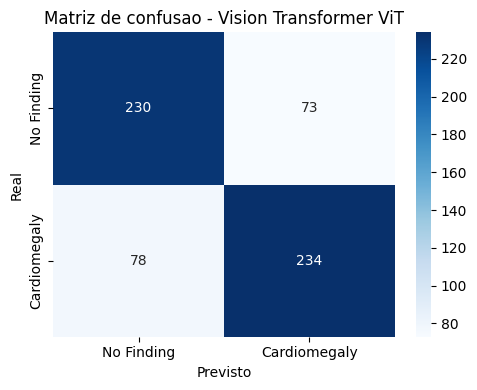

In [ ]:
def build_vit_model():
    weights = models.ViT_B_16_Weights.DEFAULT
    model = models.vit_b_16(weights=weights)
    set_requires_grad(model, False)
    in_features = model.heads.head.in_features
    model.heads.head = nn.Linear(in_features, 1)
    return model

if RUN_FULL_TRAINING and RUN_VISION_TRANSFORMER:
    vit_model = build_vit_model()
    vit_model, history_vit = fit_model(vit_model, 'Vision Transformer ViT', EPOCHS_VIT, lr=1e-3)
    display(history_vit)
    evaluate_model(vit_model, 'Vision Transformer ViT')

## 10. Comparativo entre modelos

A escolha final combina desempenho clinico simulado e eficiencia operacional. O criterio segue ranking ponderado, inspirado no notebook comparativo anterior do projeto:

- 40% F1-score, para equilibrar precision e recall.
- 30% recall, porque falso negativo em saude e especialmente critico.
- 20% AUC-ROC, para medir separabilidade global.
- 10% tempo medio de inferencia por imagem, para considerar viabilidade de uso.

Quanto menor o `selection_score`, melhor a posicao final do modelo.

,model_name,accuracy,precision,recall,specificity,f1,roc_auc,pr_auc,seconds_per_image,total_parameters,trainable_parameters,checkpoint_size_bytes,f1_rank,recall_rank,auc_roc_rank,inference_rank,selection_score,tn,fp,fn,tp,checkpoint_path
0,CNN base,0.746,0.718,0.824,0.667,0.767,0.813,0.798,0.009670,12938561,12938561,51758805,1.000000,1.000000,4.000000,1.000000,1.600,202,101,55,257,artifacts_cardioia_pytorch\modelos\cnn_base.pt
2,ResNet50,0.738,0.713,0.811,0.663,0.759,0.809,0.790,0.010907,23510081,14966785,94358661,2.000000,2.000000,5.000000,4.000000,2.800,201,102,59,253,artifacts_cardioia_pytorch\modelos\resnet50.pt
5,Vision Transformer ViT,0.754,0.762,0.750,0.759,0.756,0.833,0.805,0.009894,85799425,769,343260881,3.000000,5.000000,1.000000,2.000000,3.100,230,73,78,234,artifacts_cardioia_pytorch\modelos\vision_transformer_vit.pt
1,CNN melhorada,0.743,0.736,0.769,0.716,0.752,0.825,0.809,0.010151,1206241,1206241,4851107,4.000000,4.000000,2.000000,3.000000,3.500,217,86,72,240,artifacts_cardioia_pytorch\modelos\cnn_melhorada.pt
3,VGG16,0.733,0.714,0.792,0.673,0.751,0.817,0.806,0.011701,134264641,7083521,537068471,5.000000,3.000000,3.000000,5.000000,4.000,204,99,65,247,artifacts_cardioia_pytorch\modelos\vgg16.pt
4,EfficientNetB0,0.719,0.715,0.740,0.696,0.728,0.795,0.760,0.014000,4008829,1130673,16336305,6.000000,6.000000,6.000000,6.000000,6.000,211,92,81,231,artifacts_cardioia_pytorch\modelos\efficientnetb0.pt


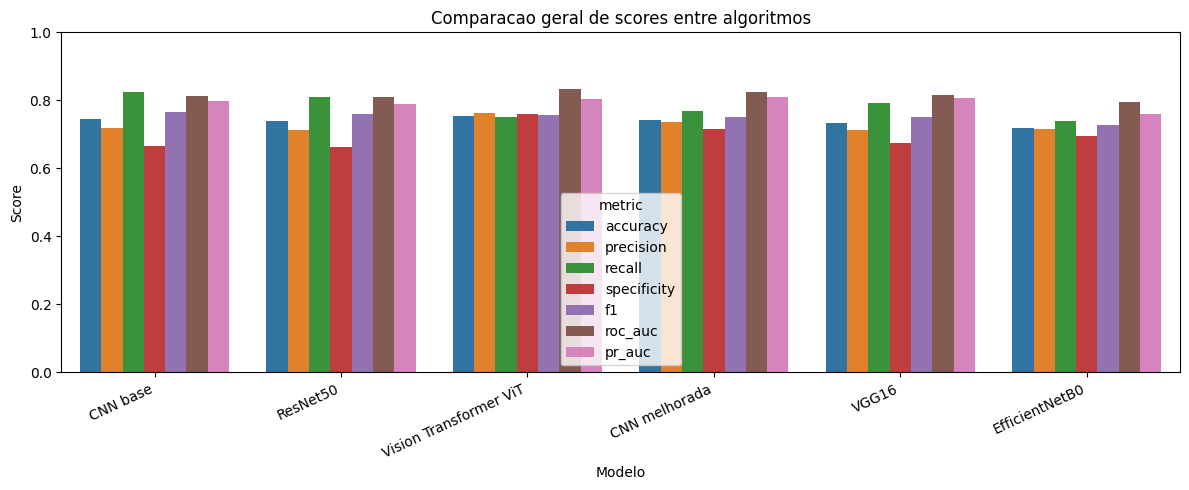

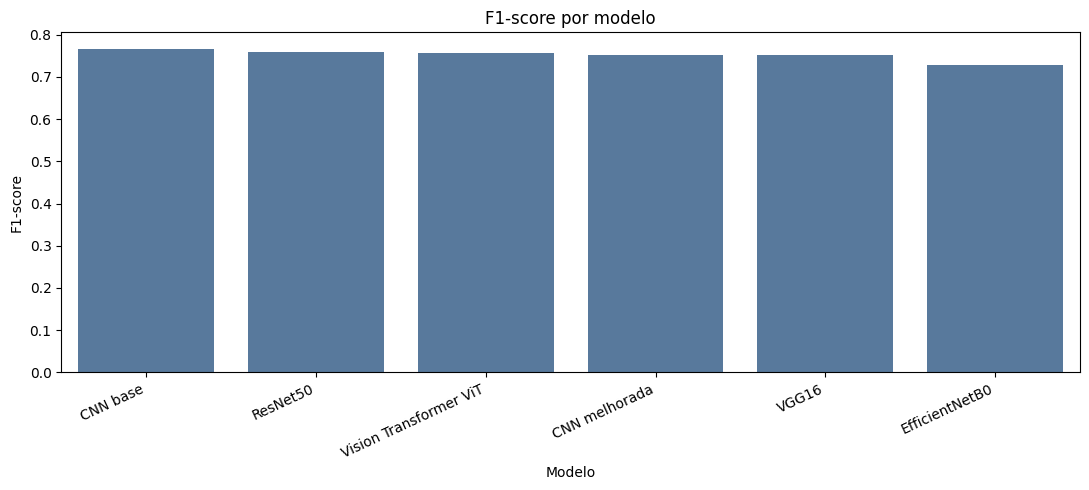

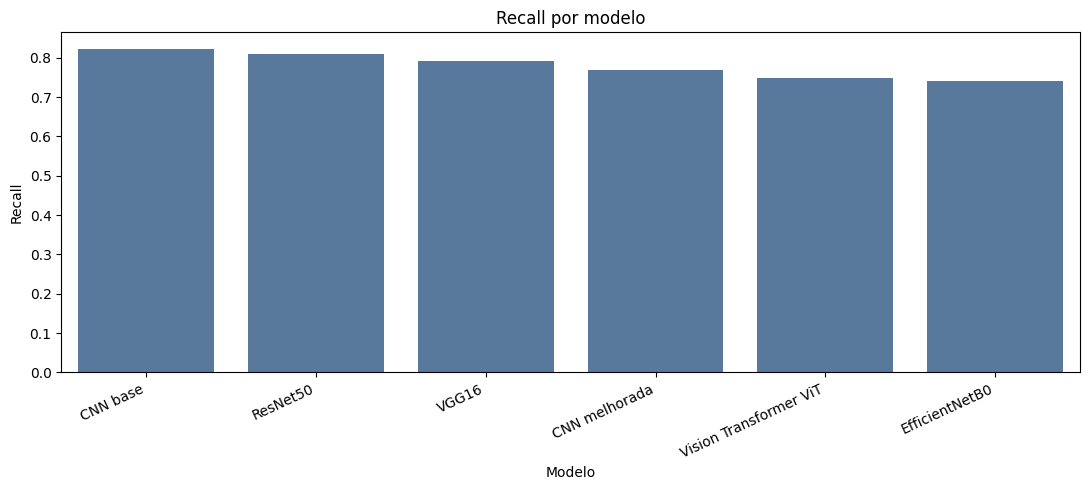

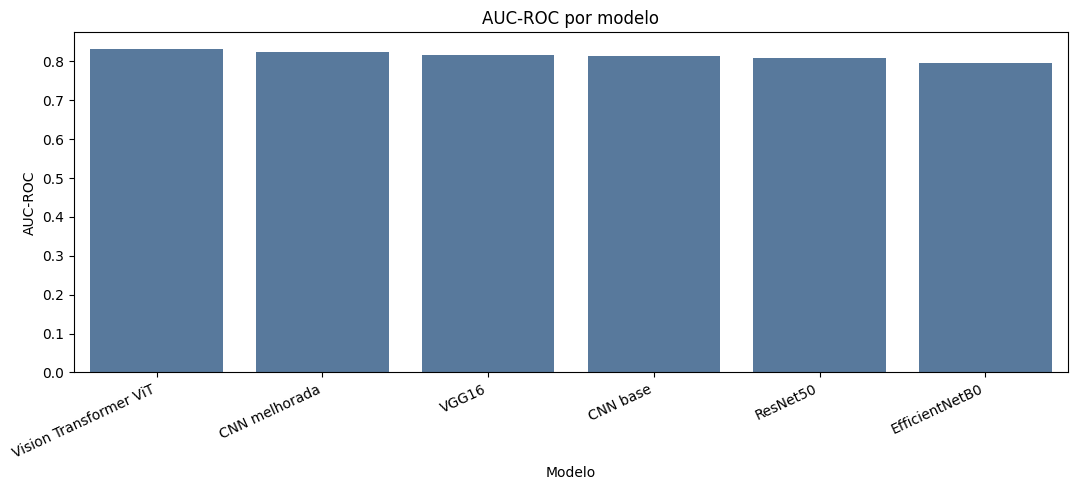

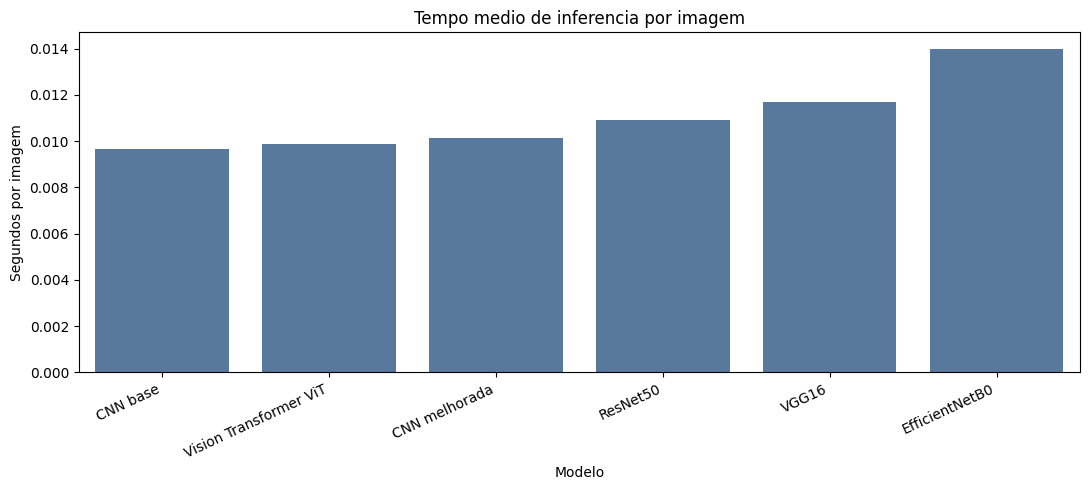

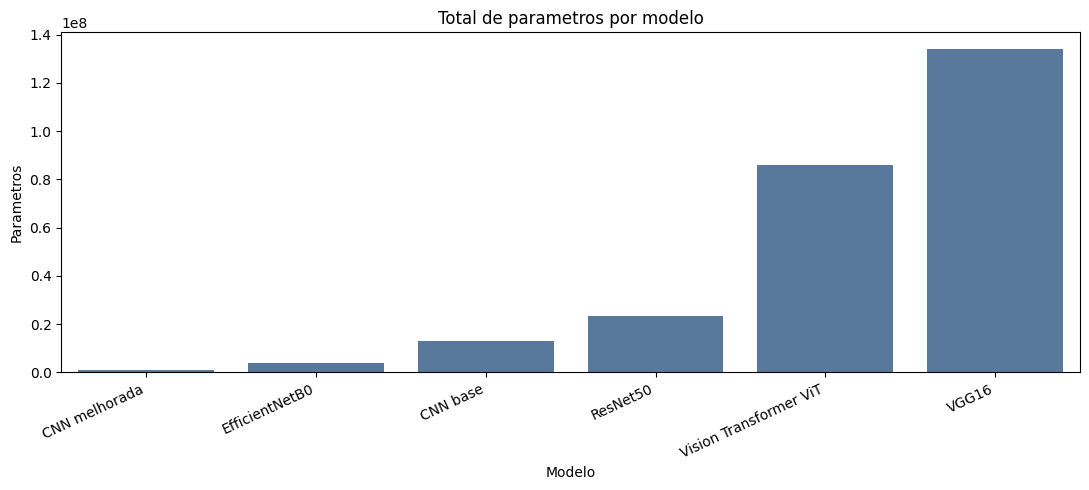

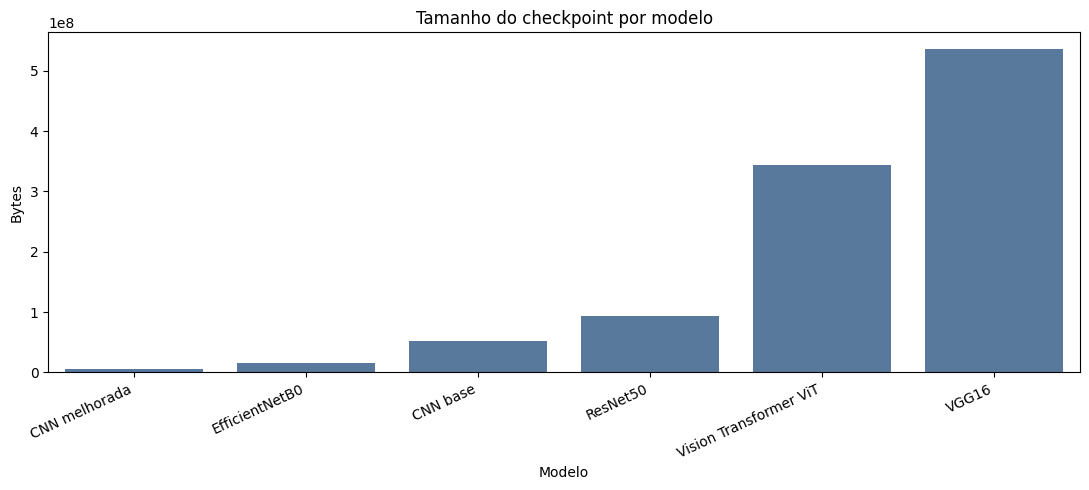

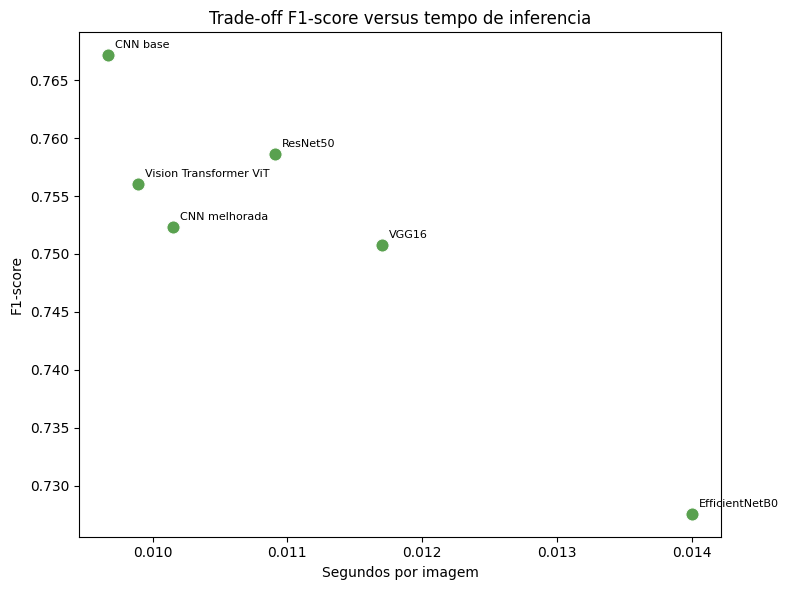

Modelo final selecionado: CNN base
Criterio: menor selection_score em ranking ponderado com 40% F1, 30% recall, 20% AUC-ROC e 10% tempo de inferencia.
Resultados no teste: F1=0.7672, recall=0.8237, AUC-ROC=0.8134, precision=0.7179, tempo=0.009670 s/imagem.
A decisao prioriza deteccao de Cardiomegaly sem ignorar custo operacional, mantendo a matriz de confusao, ajuste de threshold e fairness como verificacoes complementares.


In [ ]:
def add_selection_scores(metrics_df):
    ranked = metrics_df.copy()
    if 'auc_roc' not in ranked.columns and 'roc_auc' in ranked.columns:
        ranked['auc_roc'] = ranked['roc_auc']
    if 'model_name' not in ranked.columns:
        ranked['model_name'] = ranked['model']

    ranked['f1_rank'] = ranked['f1'].rank(ascending=False, method='min')
    ranked['recall_rank'] = ranked['recall'].rank(ascending=False, method='min')
    ranked['auc_roc_rank'] = ranked['auc_roc'].rank(ascending=False, method='min')

    if 'seconds_per_image' in ranked.columns and ranked['seconds_per_image'].notna().any():
        ranked['inference_rank'] = ranked['seconds_per_image'].rank(ascending=True, method='min')
    else:
        ranked['seconds_per_image'] = np.nan
        ranked['inference_rank'] = len(ranked)

    ranked['selection_score'] = (
        0.4 * ranked['f1_rank']
        + 0.3 * ranked['recall_rank']
        + 0.2 * ranked['auc_roc_rank']
        + 0.1 * ranked['inference_rank']
    )
    return ranked.sort_values(['selection_score', 'f1', 'recall', 'auc_roc'], ascending=[True, False, False, False])

def plot_metric_bar(data, metric, title, output_name, ascending=False, ylabel=None):
    if data.empty or metric not in data.columns:
        print(f'Grafico ignorado: {metric} indisponivel.')
        return
    plot_data = data.dropna(subset=[metric]).sort_values(metric, ascending=ascending)
    if plot_data.empty:
        print(f'Grafico ignorado: {metric} sem valores validos.')
        return

    plt.figure(figsize=(11, 5))
    sns.barplot(data=plot_data, x='model_name', y=metric, color='#4C78A8')
    plt.xticks(rotation=25, ha='right')
    plt.xlabel('Modelo')
    plt.ylabel(ylabel or metric)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / output_name, dpi=160, bbox_inches='tight')
    plt.show()

def plot_tradeoff(data):
    required_cols = {'seconds_per_image', 'f1', 'model_name'}
    if data.empty or not required_cols.issubset(data.columns):
        print('Grafico de trade-off indisponivel.')
        return
    plot_data = data.dropna(subset=['seconds_per_image', 'f1'])
    if plot_data.empty:
        print('Grafico de trade-off sem valores validos.')
        return

    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=plot_data, x='seconds_per_image', y='f1', s=90, color='#59A14F')
    for _, row in plot_data.iterrows():
        plt.annotate(row['model_name'], (row['seconds_per_image'], row['f1']), fontsize=8, xytext=(5, 5), textcoords='offset points')
    plt.xlabel('Segundos por imagem')
    plt.ylabel('F1-score')
    plt.title('Trade-off F1-score versus tempo de inferencia')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'comparacao_f1_vs_inferencia.png', dpi=160, bbox_inches='tight')
    plt.show()

if experiment_results:
    all_metrics_df = pd.DataFrame(experiment_results)
    if 'auc_roc' not in all_metrics_df.columns and 'roc_auc' in all_metrics_df.columns:
        all_metrics_df['auc_roc'] = all_metrics_df['roc_auc']
    if 'model_name' not in all_metrics_df.columns:
        all_metrics_df['model_name'] = all_metrics_df['model']

    for optional_col in ['seconds_per_image', 'total_parameters', 'trainable_parameters', 'checkpoint_size_bytes', 'checkpoint_path']:
        if optional_col not in all_metrics_df.columns:
            all_metrics_df[optional_col] = np.nan

    ranked_metrics = add_selection_scores(all_metrics_df)
    score_cols = [
        'model_name', 'accuracy', 'precision', 'recall', 'specificity', 'f1', 'roc_auc', 'pr_auc',
        'seconds_per_image', 'total_parameters', 'trainable_parameters', 'checkpoint_size_bytes',
        'f1_rank', 'recall_rank', 'auc_roc_rank', 'inference_rank', 'selection_score',
        'tn', 'fp', 'fn', 'tp', 'checkpoint_path',
    ]
    available_cols = [column for column in score_cols if column in ranked_metrics.columns]

    all_metrics_df.to_csv(TABLES_DIR / 'model_comparison_all_metrics.csv', index=False)
    ranked_metrics.to_csv(TABLES_DIR / 'model_comparison_ranked.csv', index=False)
    ranked_metrics.to_csv(ARTIFACT_DIR / 'comparativo_modelos.csv', index=False)

    format_cols = {column: '{:.3f}' for column in ['accuracy', 'precision', 'recall', 'specificity', 'f1', 'roc_auc', 'pr_auc', 'selection_score'] if column in ranked_metrics.columns}
    if 'seconds_per_image' in ranked_metrics.columns:
        format_cols['seconds_per_image'] = '{:.6f}'
    display(ranked_metrics[available_cols].style.format(format_cols))

    performance_plot_df = ranked_metrics.melt(
        id_vars='model_name',
        value_vars=[metric for metric in ['accuracy', 'precision', 'recall', 'specificity', 'f1', 'roc_auc', 'pr_auc'] if metric in ranked_metrics.columns],
        var_name='metric',
        value_name='score',
    )
    plt.figure(figsize=(12, 5))
    sns.barplot(data=performance_plot_df, x='model_name', y='score', hue='metric')
    plt.ylim(0, 1)
    plt.xticks(rotation=25, ha='right')
    plt.xlabel('Modelo')
    plt.ylabel('Score')
    plt.title('Comparacao geral de scores entre algoritmos')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'comparacao_scores_geral.png', dpi=160, bbox_inches='tight')
    plt.show()

    plot_metric_bar(ranked_metrics, 'f1', 'F1-score por modelo', 'comparacao_f1_por_modelo.png', ascending=False, ylabel='F1-score')
    plot_metric_bar(ranked_metrics, 'recall', 'Recall por modelo', 'comparacao_recall_por_modelo.png', ascending=False, ylabel='Recall')
    plot_metric_bar(ranked_metrics, 'roc_auc', 'AUC-ROC por modelo', 'comparacao_auc_por_modelo.png', ascending=False, ylabel='AUC-ROC')
    plot_metric_bar(ranked_metrics, 'seconds_per_image', 'Tempo medio de inferencia por imagem', 'comparacao_inferencia_por_modelo.png', ascending=True, ylabel='Segundos por imagem')
    plot_metric_bar(ranked_metrics, 'total_parameters', 'Total de parametros por modelo', 'comparacao_parametros_por_modelo.png', ascending=True, ylabel='Parametros')
    plot_metric_bar(ranked_metrics, 'checkpoint_size_bytes', 'Tamanho do checkpoint por modelo', 'comparacao_tamanho_checkpoint_por_modelo.png', ascending=True, ylabel='Bytes')
    plot_tradeoff(ranked_metrics)

    best_model_name = ranked_metrics.iloc[0]['model']
    final_selection = ranked_metrics.iloc[[0]][available_cols]
    final_selection.to_csv(TABLES_DIR / 'final_model_selection.csv', index=False)

    final_row = ranked_metrics.iloc[0]
    if pd.isna(final_row['seconds_per_image']):
        inference_text = 'nao recalculado nesta execucao'
    else:
        inference_text = f"{final_row['seconds_per_image']:.6f} s/imagem"
    justification = (
        f"Modelo final selecionado: {final_row['model_name']}\n"
        f"Criterio: menor selection_score em ranking ponderado com 40% F1, 30% recall, 20% AUC-ROC e 10% tempo de inferencia.\n"
        f"Resultados no teste: F1={final_row['f1']:.4f}, recall={final_row['recall']:.4f}, "
        f"AUC-ROC={final_row['roc_auc']:.4f}, precision={final_row['precision']:.4f}, "
        f"tempo={inference_text}.\n"
        "A decisao prioriza deteccao de Cardiomegaly sem ignorar custo operacional, mantendo a matriz de confusao, ajuste de threshold e fairness como verificacoes complementares."
    )
    (ARTIFACT_DIR / 'justificativa_modelo_final.txt').write_text(justification, encoding='utf-8')
    print(justification)
else:
    ranked_metrics = pd.DataFrame()
    print('Nenhum modelo treinado ainda.')

## 11. Ajuste de threshold

O threshold padrao e 0.5. Para contexto de saude, pode ser interessante reduzir o threshold para aumentar recall, aceitando mais falsos positivos.

,threshold,precision,recall,specificity,f1,roc_auc,pr_auc
9,0.50,0.717877,0.823718,0.666667,0.767164,0.813394,0.798475
6,0.35,0.660465,0.910256,0.518152,0.765499,0.813394,0.798475
7,0.40,0.672372,0.881410,0.557756,0.762829,0.813394,0.798475
8,0.45,0.688312,0.849359,0.603960,0.760402,0.813394,0.798475
5,0.30,0.641593,0.929487,0.465347,0.759162,0.813394,0.798475
10,0.55,0.736364,0.778846,0.712871,0.757009,0.813394,0.798475
4,0.25,0.618143,0.939103,0.402640,0.745547,0.813394,0.798475
11,0.60,0.745161,0.740385,0.739274,0.742765,0.813394,0.798475
3,0.20,0.602823,0.958333,0.349835,0.740099,0.813394,0.798475
12,0.65,0.779783,0.692308,0.798680,0.733447,0.813394,0.798475


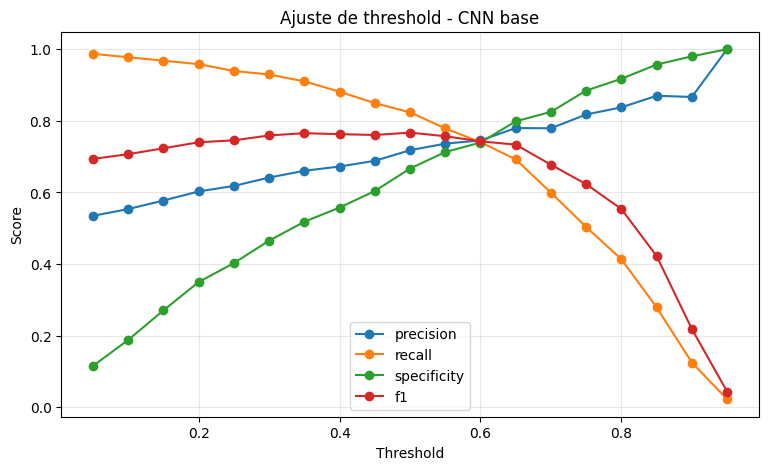

In [ ]:
def threshold_sweep(y_true, y_proba):
    rows = []
    for threshold in np.linspace(0.05, 0.95, 19):
        row = compute_metrics(y_true, y_proba, threshold=float(threshold))
        rows.append(row)
    return pd.DataFrame(rows)

if experiment_results:
    best_preds = predictions_registry[best_model_name]
    sweep_df = threshold_sweep(best_preds['y_true'].values, best_preds['y_proba'].values)
    display(sweep_df[['threshold', 'precision', 'recall', 'specificity', 'f1', 'roc_auc', 'pr_auc']].sort_values('f1', ascending=False).head(10))

    plt.figure(figsize=(9, 5))
    for metric in ['precision', 'recall', 'specificity', 'f1']:
        plt.plot(sweep_df['threshold'], sweep_df[metric], marker='o', label=metric)
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title(f'Ajuste de threshold - {best_model_name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 12. Fairness e governanca

Avaliamos governanca em duas camadas: primeiro, representatividade dos subgrupos no teste; depois, desempenho do modelo final por subgrupo. Essa leitura nao prova seguranca clinica nem ausencia de vies, mas documenta riscos importantes para a entrega academica.

Metricas acompanhadas:

- representatividade por classe, genero, faixa etaria e posicao da imagem;
- selection rate, isto e, taxa de predicao positiva;
- recall por grupo, tambem chamado de equal opportunity;
- false positive rate e false negative rate;
- demographic parity gap;
- equal opportunity gap;
- marcacao de subgrupos com baixa amostra.

,group_col,group,n,positives,predicted_positives,sample_share,base_rate_true_positive,selection_rate_predicted_positive,low_sample_warning
0,y_true,1,312,312,257,0.507317,1.000000,0.823718,False
1,y_true,0,303,0,101,0.492683,0.000000,0.333333,False
2,Patient Gender,M,357,179,187,0.580488,0.501401,0.523810,False
3,Patient Gender,F,258,133,171,0.419512,0.515504,0.662791,False
4,age_group,41-60,291,152,168,0.473171,0.522337,0.577320,False
5,age_group,19-40,152,65,80,0.247154,0.427632,0.526316,False
6,age_group,61-80,120,63,69,0.195122,0.525000,0.575000,False
7,age_group,0-18,49,30,38,0.079675,0.612245,0.775510,False
8,age_group,81+,3,2,3,0.004878,0.666667,1.000000,True
9,View Position,PA,359,153,184,0.583740,0.426184,0.512535,False


,group_col,group,n,skipped_low_sample,base_rate_true_positive,selection_rate_predicted_positive,accuracy,precision,recall_equal_opportunity,f1,roc_auc,specificity,false_positive_rate,false_negative_rate,tn,fp,fn,tp
0,Patient Gender,F,258,False,0.515504,0.662791,0.751938,0.701754,0.902256,0.789474,0.832782,0.592000,0.408000,0.097744,74,51,13,120
1,Patient Gender,M,357,False,0.501401,0.523810,0.742297,0.732620,0.765363,0.748634,0.806478,0.719101,0.280899,0.234637,128,50,42,137
2,age_group,0-18,49,False,0.612245,0.775510,0.795918,0.763158,0.966667,0.852941,0.870175,0.526316,0.473684,0.033333,10,9,1,29
3,age_group,19-40,152,False,0.427632,0.526316,0.717105,0.637500,0.784615,0.703448,0.784262,0.666667,0.333333,0.215385,58,29,14,51
4,age_group,41-60,291,False,0.522337,0.577320,0.766323,0.750000,0.828947,0.787500,0.840543,0.697842,0.302158,0.171053,97,42,26,126
5,age_group,61-80,120,False,0.525000,0.575000,0.716667,0.710145,0.777778,0.742424,0.763297,0.649123,0.350877,0.222222,37,20,14,49
6,age_group,81+,3,True,0.666667,1.000000,0.666667,0.666667,1.000000,0.800000,0.000000,0.000000,1.000000,0.000000,0,1,0,2
7,View Position,AP,256,False,0.621094,0.679688,0.730469,0.758621,0.830189,0.792793,0.750308,0.567010,0.432990,0.169811,55,42,27,132
8,View Position,PA,359,False,0.426184,0.512535,0.757660,0.679348,0.816993,0.741840,0.846818,0.713592,0.286408,0.183007,147,59,28,125


,group_col,min_group_n,max_group_n,demographic_parity_gap,demographic_parity_gap_worst_group,demographic_parity_gap_best_group,equal_opportunity_recall_gap,equal_opportunity_recall_gap_worst_group,equal_opportunity_recall_gap_best_group,fpr_gap,...,fpr_gap_best_group,fnr_gap,fnr_gap_worst_group,fnr_gap_best_group,precision_gap,precision_gap_worst_group,precision_gap_best_group,f1_gap,f1_gap_worst_group,f1_gap_best_group
0,Patient Gender,258,357,0.138981,M,F,0.136893,M,F,0.127101,...,F,0.136893,F,M,0.030866,F,M,0.040840,M,F
1,View Position,256,359,0.167153,PA,AP,0.013195,PA,AP,0.146582,...,AP,0.013195,AP,PA,0.079273,PA,AP,0.050953,PA,AP
2,age_group,49,291,0.249194,19-40,0-18,0.188889,61-80,0-18,0.171526,...,0-18,0.188889,0-18,61-80,0.125658,19-40,0-18,0.149493,19-40,0-18


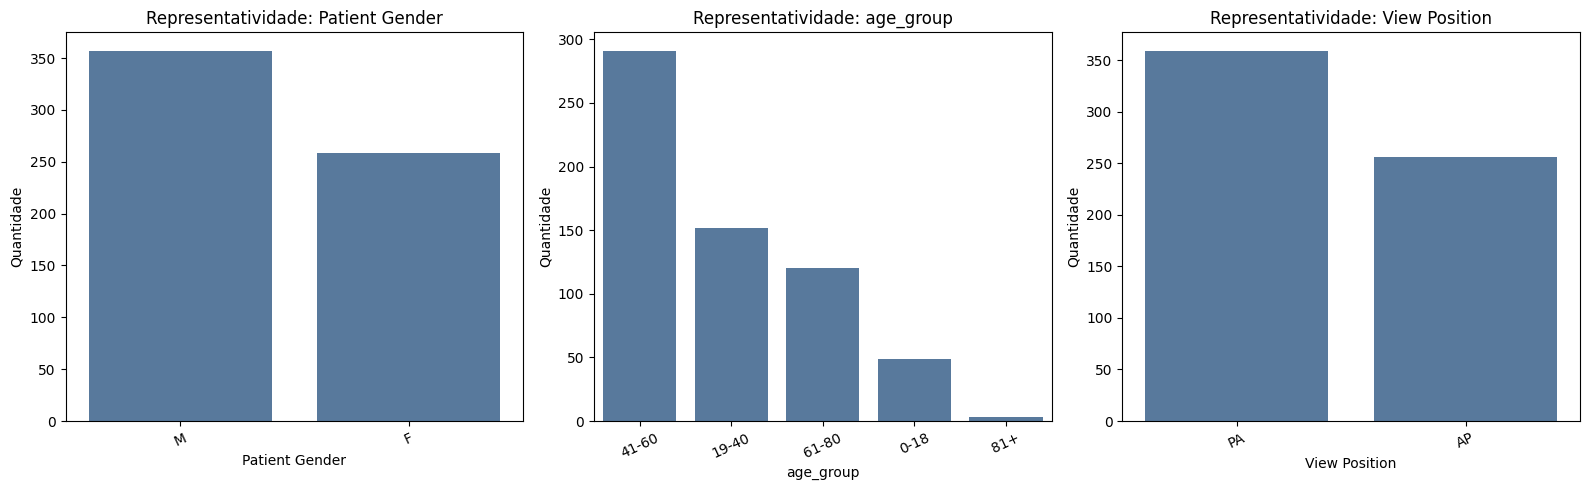

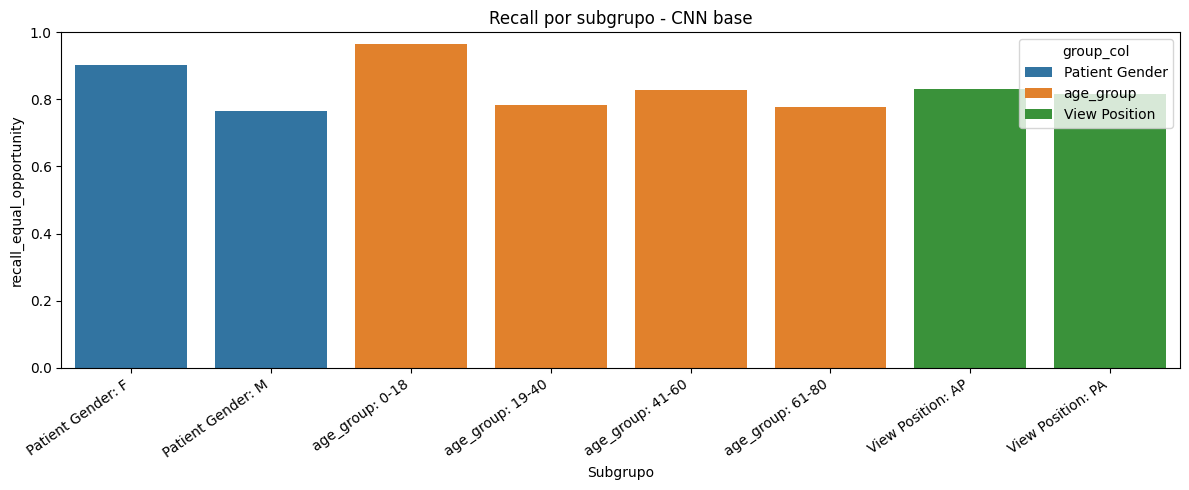

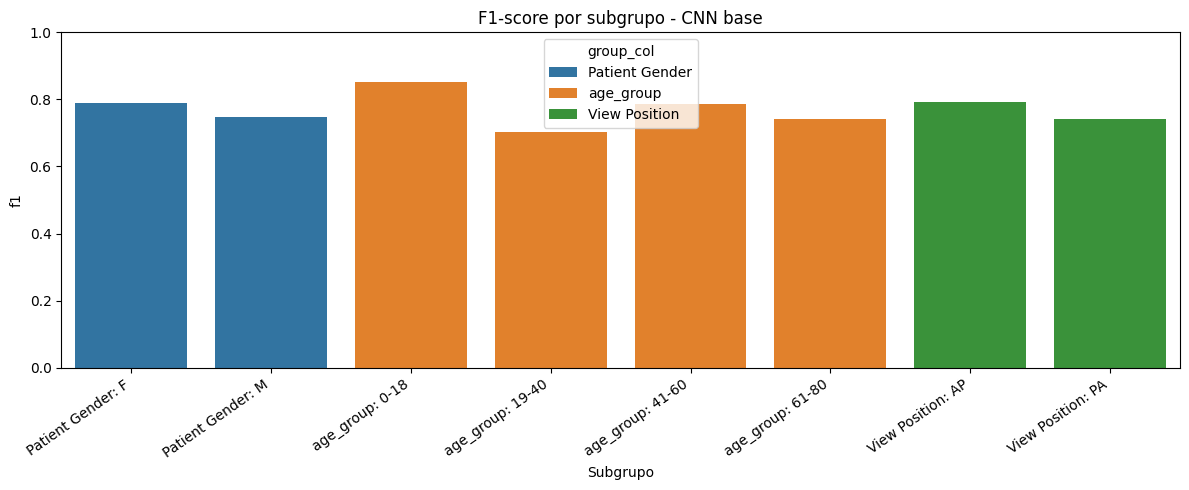

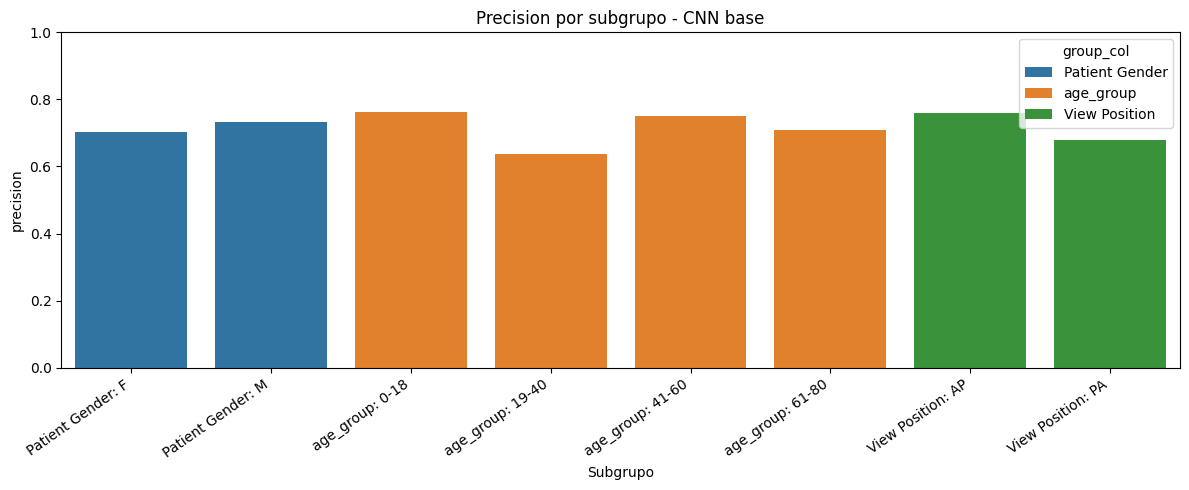

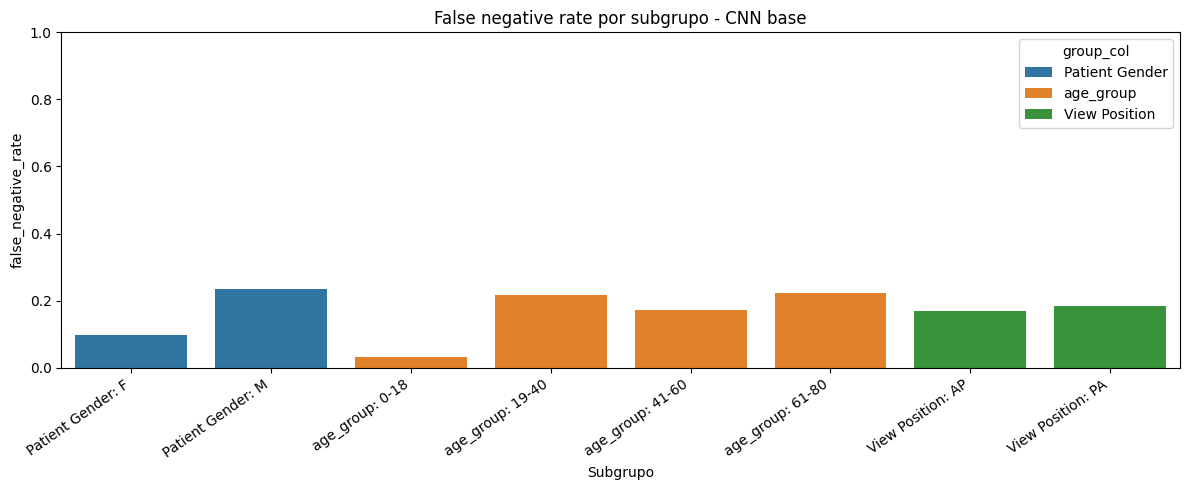

# Governanca, Fairness e Limitacoes

A analise foi realizada no conjunto de teste para o modelo final `CNN base`. Foram avaliados genero, faixa etaria e posicao da imagem, alem da representatividade por classe real.

## Representatividade

Subgrupos com menos de 10 amostras foram marcados com `skipped_low_sample`, pois metricas com poucas observacoes podem oscilar muito e nao devem sustentar conclusoes fortes.

## Metricas por subgrupo

Foram calculadas accuracy, precision, recall, F1-score, AUC-ROC, specificity, false positive rate e false negative rate. O recall e o false negative rate merecem destaque porque falsos negativos em um contexto de saude podem atrasar investigacao clinica.

## Maiores gaps observados

     group_col                   metric_gap      gap
     age_group       demographic_parity_gap 0.249194
     age_group equal_opportunity_recall_gap 0.188889
     age_group                      fnr_gap 0.188889
     age_group                      fpr_gap 0.171526
 View Posi

In [ ]:
MIN_SUBGROUP_SAMPLES = 10
FAIRNESS_GROUP_COLUMNS = ['Patient Gender', 'age_group', 'View Position']

def add_age_group(frame):
    output = frame.copy()
    output['age_group'] = pd.cut(
        output['Patient Age'],
        bins=[0, 18, 40, 60, 80, 120],
        labels=['0-18', '19-40', '41-60', '61-80', '81+'],
        include_lowest=True,
    )
    return output

def ensure_fairness_metadata(pred_df, split_df):
    output = pred_df.copy()
    metadata_cols = ['Image Index', 'Patient ID', 'Patient Gender', 'Patient Age', 'View Position']
    missing_cols = [column for column in metadata_cols if column not in output.columns]
    if missing_cols:
        output = output.merge(split_df[['Image Index', *[column for column in missing_cols if column != 'Image Index']]], on='Image Index', how='left')
    return add_age_group(output)

def representation_table(data, group_col):
    table = (
        data.assign(_group=data[group_col].astype('string').fillna('Unknown'))
        .groupby('_group', dropna=False)
        .agg(
            n=('Image Index', 'count'),
            positives=('y_true', 'sum'),
            predicted_positives=('y_pred', 'sum'),
        )
        .reset_index()
        .rename(columns={'_group': 'group'})
    )
    table.insert(0, 'group_col', group_col)
    table['sample_share'] = table['n'] / len(data)
    table['base_rate_true_positive'] = table['positives'] / table['n']
    table['selection_rate_predicted_positive'] = table['predicted_positives'] / table['n']
    table['low_sample_warning'] = table['n'] < MIN_SUBGROUP_SAMPLES
    return table.sort_values(['group_col', 'n'], ascending=[True, False])

def group_fairness_metrics(pred_df, group_col, min_samples=MIN_SUBGROUP_SAMPLES):
    rows = []
    prepared = pred_df.assign(_group=pred_df[group_col].astype('string').fillna('Unknown'))
    for group_value, group in prepared.groupby('_group', dropna=False):
        y_true = group['y_true'].astype(int).values
        y_pred = group['y_pred'].astype(int).values
        y_proba = group['y_proba'].values if 'y_proba' in group.columns else np.full(len(group), np.nan)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        specificity = tn / (tn + fp) if (tn + fp) else np.nan
        fpr = fp / (fp + tn) if (fp + tn) else np.nan
        fnr = fn / (fn + tp) if (fn + tp) else np.nan
        subgroup_auc = roc_auc_score(y_true, y_proba) if len(np.unique(y_true)) == 2 else np.nan
        rows.append({
            'group_col': group_col,
            'group': str(group_value),
            'n': len(group),
            'skipped_low_sample': len(group) < min_samples,
            'base_rate_true_positive': y_true.mean(),
            'selection_rate_predicted_positive': y_pred.mean(),
            'accuracy': accuracy_score(y_true, y_pred),
            'precision': precision_score(y_true, y_pred, zero_division=0),
            'recall_equal_opportunity': recall_score(y_true, y_pred, zero_division=0),
            'f1': f1_score(y_true, y_pred, zero_division=0),
            'roc_auc': subgroup_auc,
            'specificity': specificity,
            'false_positive_rate': fpr,
            'false_negative_rate': fnr,
            'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
        })
    return pd.DataFrame(rows)

def summarize_fairness_gaps(fair_df):
    rows = []
    metrics_to_gap = {
        'selection_rate_predicted_positive': 'demographic_parity_gap',
        'recall_equal_opportunity': 'equal_opportunity_recall_gap',
        'false_positive_rate': 'fpr_gap',
        'false_negative_rate': 'fnr_gap',
        'precision': 'precision_gap',
        'f1': 'f1_gap',
    }
    eligible = fair_df[~fair_df['skipped_low_sample']].copy()
    for group_col, sub in eligible.groupby('group_col'):
        row = {'group_col': group_col, 'min_group_n': sub['n'].min(), 'max_group_n': sub['n'].max()}
        for metric, gap_name in metrics_to_gap.items():
            row[gap_name] = sub[metric].max() - sub[metric].min()
            row[f'{gap_name}_worst_group'] = sub.loc[sub[metric].idxmin(), 'group'] if sub[metric].notna().any() else np.nan
            row[f'{gap_name}_best_group'] = sub.loc[sub[metric].idxmax(), 'group'] if sub[metric].notna().any() else np.nan
        rows.append(row)
    return pd.DataFrame(rows)

def plot_fairness_metric(fair_df, metric, title, output_name):
    plot_data = fair_df[~fair_df['skipped_low_sample']].dropna(subset=[metric]).copy()
    if plot_data.empty:
        print(f'Sem subgrupos suficientes para grafico de {metric}.')
        return
    plot_data['subgroup'] = plot_data['group_col'] + ': ' + plot_data['group']
    plt.figure(figsize=(12, 5))
    sns.barplot(data=plot_data, x='subgroup', y=metric, hue='group_col', dodge=False)
    plt.ylim(0, 1)
    plt.xlabel('Subgrupo')
    plt.ylabel(metric)
    plt.title(title)
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / output_name, dpi=160, bbox_inches='tight')
    plt.show()

if experiment_results:
    fairness_base = ensure_fairness_metadata(predictions_registry[best_model_name], test_df)
    representation_df = pd.concat(
        [representation_table(fairness_base, group_col) for group_col in ['y_true', *FAIRNESS_GROUP_COLUMNS]],
        ignore_index=True,
    )
    fairness_df = pd.concat(
        [group_fairness_metrics(fairness_base, group_col) for group_col in FAIRNESS_GROUP_COLUMNS],
        ignore_index=True,
    )
    fairness_gap_df = summarize_fairness_gaps(fairness_df)

    display(representation_df)
    display(fairness_df)
    display(fairness_gap_df)

    representation_df.to_csv(TABLES_DIR / 'fairness_representatividade_teste.csv', index=False)
    fairness_df.to_csv(TABLES_DIR / 'fairness_metricas_por_subgrupo.csv', index=False)
    fairness_gap_df.to_csv(TABLES_DIR / 'fairness_gaps_por_subgrupo.csv', index=False)
    fairness_df.to_csv(ARTIFACT_DIR / 'fairness_por_grupo.csv', index=False)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, column in zip(axes, FAIRNESS_GROUP_COLUMNS):
        counts = fairness_base[column].astype('string').fillna('Unknown').value_counts().reset_index()
        counts.columns = [column, 'image_count']
        sns.barplot(data=counts, x=column, y='image_count', ax=ax, color='#4C78A8')
        ax.set_title(f'Representatividade: {column}')
        ax.set_xlabel(column)
        ax.set_ylabel('Quantidade')
        ax.tick_params(axis='x', rotation=25)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'fairness_representatividade_subgrupos.png', dpi=160, bbox_inches='tight')
    plt.show()

    plot_fairness_metric(fairness_df, 'recall_equal_opportunity', f'Recall por subgrupo - {best_model_name}', 'fairness_recall_por_subgrupo.png')
    plot_fairness_metric(fairness_df, 'f1', f'F1-score por subgrupo - {best_model_name}', 'fairness_f1_por_subgrupo.png')
    plot_fairness_metric(fairness_df, 'precision', f'Precision por subgrupo - {best_model_name}', 'fairness_precision_por_subgrupo.png')
    plot_fairness_metric(fairness_df, 'false_negative_rate', f'False negative rate por subgrupo - {best_model_name}', 'fairness_fnr_por_subgrupo.png')

    largest_gap_rows = []
    for _, row in fairness_gap_df.iterrows():
        for gap_col in [col for col in fairness_gap_df.columns if col.endswith('_gap')]:
            largest_gap_rows.append({'group_col': row['group_col'], 'metric_gap': gap_col, 'gap': row[gap_col]})
    largest_gaps = pd.DataFrame(largest_gap_rows).dropna().sort_values('gap', ascending=False).head(8)

    fairness_discussion = f"""
# Governanca, Fairness e Limitacoes

A analise foi realizada no conjunto de teste para o modelo final `{best_model_name}`. Foram avaliados genero, faixa etaria e posicao da imagem, alem da representatividade por classe real.

## Representatividade

Subgrupos com menos de {MIN_SUBGROUP_SAMPLES} amostras foram marcados com `skipped_low_sample`, pois metricas com poucas observacoes podem oscilar muito e nao devem sustentar conclusoes fortes.

## Metricas por subgrupo

Foram calculadas accuracy, precision, recall, F1-score, AUC-ROC, specificity, false positive rate e false negative rate. O recall e o false negative rate merecem destaque porque falsos negativos em um contexto de saude podem atrasar investigacao clinica.

## Maiores gaps observados

{largest_gaps.to_string(index=False) if not largest_gaps.empty else 'Nao foi possivel calcular gaps com os dados disponiveis.'}

## Limites de uso

Este prototipo nao substitui avaliacao medica. O dataset NIH ChestX-ray14 possui labels derivados de laudos e pode conter ruido de anotacao. Antes de uso real seriam necessarias validacao clinica externa, revisao por especialistas, auditoria de vies, governanca de dados e monitoramento continuo.
""".strip()
    (ARTIFACT_DIR / 'fairness_discussao.md').write_text(fairness_discussion + '\n', encoding='utf-8')
    print(fairness_discussion)
else:
    print('Nenhum modelo treinado ainda; execute a avaliacao dos modelos antes da fairness.')

## 13. Conclusao e interpretacao

Este projeto construiu um pipeline completo de classificacao binaria para identificar imagens com indicio de `Cardiomegaly` em comparacao com imagens `No Finding` no dataset NIH Chest X-rays. A solucao partiu de uma analise exploratoria dos metadados, passou pela definicao de um recorte clinico-academico, realizou split por paciente para reduzir vazamento de informacao e avaliou diferentes familias de modelos de visao computacional em PyTorch.

A EDA mostrou que o dataset original e multi-label e possui diferencas relevantes de distribuicao entre achados, pacientes, idade, genero e posicao da imagem. Por isso, o problema foi tratado como uma simplificacao controlada: o objetivo nao foi diagnosticar todas as doencas toracicas, mas testar um fluxo de classificacao focado em cardiomegalia. O split por `Patient ID` foi mantido como decisao metodologica importante, pois evita que imagens do mesmo paciente aparecam em treino e teste, o que inflaria artificialmente as metricas.

Foram treinadas e avaliadas seis abordagens: `CNN base`, `CNN melhorada`, `ResNet50`, `VGG16`, `EfficientNetB0` e `Vision Transformer ViT`. A comparacao nao considerou apenas acuracia; foram avaliados precision, recall, specificity, F1-score, AUC-ROC, PR-AUC, matriz de confusao, tempo medio de inferencia, quantidade de parametros e tamanho do checkpoint. Para escolher o modelo final, foi usado um ranking ponderado com 40% de peso para F1-score, 30% para recall, 20% para AUC-ROC e 10% para tempo de inferencia.

Na execucao atual, o modelo final selecionado foi a **CNN base**. No conjunto de teste, ela atingiu `accuracy=0.7463`, `precision=0.7179`, `recall=0.8237`, `specificity=0.6667`, `F1=0.7672`, `AUC-ROC=0.8134` e `PR-AUC=0.7985`. A matriz de confusao registrou `TN=202`, `FP=101`, `FN=55` e `TP=257`. O resultado mostra que o modelo priorizou a recuperacao de casos positivos, reduzindo falsos negativos em relacao ao objetivo de triagem, ainda que isso tenha aumentado a quantidade de falsos positivos.

A escolha da CNN base tambem e relevante do ponto de vista de eficiencia. Embora modelos mais modernos tenham apresentado bons resultados em algumas metricas, a CNN base obteve o melhor equilibrio no criterio definido: maior F1-score, maior recall e menor tempo medio de inferencia entre os modelos testados. O `Vision Transformer ViT`, por exemplo, obteve a maior AUC-ROC, mas ficou atras no ranking ponderado por apresentar recall menor e checkpoint muito maior. Isso reforca que o modelo mais complexo nem sempre e o mais adequado quando o criterio combina desempenho, custo e objetivo do problema.

A etapa de ajuste de threshold foi incluida porque o limiar padrao de 0.5 pode nao ser o ideal em um contexto de saude. Para triagem, pode fazer sentido reduzir o threshold para aumentar recall e diminuir falsos negativos, aceitando mais falsos positivos. Essa decisao, porem, nao deve ser automatica: ela depende do custo clinico de cada erro, da revisao humana posterior e do ambiente de uso.

Na analise de fairness, foram avaliados subgrupos por genero, faixa etaria e `View Position`. Os maiores gaps observados indicam que idade e posicao da imagem merecem atencao especial: a diferenca de selection rate por faixa etaria chegou a aproximadamente 0.2492, e a diferenca por `View Position` chegou a aproximadamente 0.1672. Tambem foram observadas diferencas de equal opportunity por genero e idade. Esses resultados nao provam discriminacao, mas mostram risco de desempenho desigual entre subgrupos e justificam monitoramento, validacao externa e revisao dos dados antes de qualquer uso real.

Como limitacoes, o NIH ChestX-ray14 possui labels derivados de laudos por processamento de linguagem natural, o que pode introduzir ruido de anotacao. Alem disso, o recorte binario simplifica um problema originalmente multi-label, nao ha validacao externa em outro hospital ou populacao, e o desempenho foi medido em contexto academico. Portanto, este notebook deve ser interpretado como prova de conceito tecnica e nao como ferramenta clinica.

Mitigacoes adotadas e recomendadas:

- uso de split por paciente para reduzir vazamento de informacao;
- avaliacao por matriz de confusao e metricas alem da acuracia;
- comparacao entre modelos simples, transfer learning e transformer;
- acompanhamento explicito de falsos negativos;
- analise de threshold para cenarios de triagem;
- fairness por genero, idade e posicao da imagem;
- documentacao de limitacoes, vieses potenciais e uso estritamente academico;
- necessidade de validacao externa e revisao humana especializada antes de qualquer aplicacao real.

Em resumo, o projeto entrega um pipeline reprodutivel e auditavel para classificacao de cardiomegalia em raio-X, com preocupacao nao apenas em treinar um modelo, mas em justificar escolhas, comparar alternativas, medir riscos e documentar limites. O resultado final favorece uma CNN simples, eficiente e com bom recall, mostrando que uma solucao menor pode ser competitiva quando o criterio de decisao esta bem definido.